# EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение и ИИ  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Titanic  

**Выполнил:** Емельянова Ксения Павловна  
**Группа:** ПКТб-23-1  
**Преподаватель:** Спирин Игорь Сергеевич  

**Ссылка на репозиторий:** https://github.com/fivifri/ml-course-emelyanova  
**Путь к модулю:** `module-1-titanic/notebook.ipynb`  
**Дата сдачи:** 2026-29-09

## Введение

**Задача:** бинарная классификация — предсказать, выжил ли пассажир Titanic (0 — не выжил, 1 — выжил).

**Что такое ML-проект:** ML-проект — это полный жизненный цикл создания интеллектуального решения, который начинается с анализа бизнеса и сбора данных, продолжается их подготовкой, EDA и созданием признаков, а завершается обучением, подбором моделей, их оценкой и внедрением. Это итеративный процесс, где результаты оценки часто заставляют возвращаться к начальным этапам для улучшения качества.

**Почему классификация, а не регрессия:** Целевая переменная является дискретной и принимает значения из ограниченного множества классов (выжил / не выжил), а не непрерывным числовым значением (как, например, цена квартиры или температура). Регрессия предсказывает непрерывную величину, тогда как классификация разделяет объекты по категориям.

**Какая метрика важнее:** В этой задаче наиболее информативной метрикой является **ROC-AUC**, так как она оценивает способность модели ранжировать пассажиров по вероятности выживания независимо от выбранного порога классификации и устойчива к возможному дисбалансу классов. Для оценки качества на фиксированном пороге лучше использовать **F1-score**, поскольку она гармонично объединяет точность (Precision) и полноту (Recall), в отличие от Accuracy, которая может давать обманчиво высокий результат при дисбалансе.

**Цель работы:**
1. Провести полный EDA датасета Титаник.
2. Обучить 2+ модели и достичь ROC-AUC ≥ 0.80.
3. Реализовать функцию предсказания для нового пассажира.

## Теоретический обзор ключевых понятий ML

### 1. EDA (Exploratory Data Analysis)
Разведочный анализ данных (EDA) — это первичный этап исследования датасета, направленный на понимание его структуры, природы и внутренних закономерностей. Он необходим для того, чтобы увидеть «полную картину» данных до того, как подавать их в алгоритмы машинного обучения. В процессе EDA исследователь проверяет типы данных, находит пропуски, выявляет аномалии и выбросы, а также изучает распределения признаков. Кроме того, на этом этапе анализируются корреляции между фичами и целевой переменной, что помогает сформировать гипотезы для дальнейшей предобработки. Без качественного EDA высок риск обучить модель на нерелевантной или искаженной информации.

---

### 2. Пропуски (NaN)
Пропущенные значения возникают по разным причинам: от сбоев при сборе и записи данных до нежелания пользователей заполнять необязательные поля анкеты. Обработка пропусков критически важна, так как большинство классических ML-моделей не умеют работать с `NaN` напрямую. Выбор стратегии зависит от природы данных: строки или столбцы с большим количеством пропусков можно просто удалить, если это не приведет к потере важной информации. В остальных случаях применяют импутацию — заполнение пропусков медианой или средним значением для числовых признаков, либо модой для категориальных. Для сложных взаимосвязей также используют заполнение с помощью моделей (например, KNN) или выделение факта отсутствия значения в отдельный бинарный признак-индикатор.

---

### 3. Кодирование категориальных признаков
Категориальные переменные содержат текстовые метки или группы, которые необходимо перевести в числовой формат для восприятия алгоритмами. При **Label Encoding** каждой уникальной категории присваивается целое число (0, 1, 2...), однако этот метод может создать ложное представление об иерархии или порядке категорий там, где его нет. В свою очередь, **One-Hot Encoding** преобразует одну категориальную колонку в $N$ бинарных столбцов (0 или 1), где $N$ — количество уникальных значений. One-Hot идеален для нелинейных категорий, но может сильно раздуть размерность датасета при высоком кардинале признака.

---

### 4. Масштабирование признаков
Масштабирование необходимо для того, чтобы признаки с большими значениями (например, доход или цена) не перевешивали признаки с малыми значениями (например, возраст) в моделях, чувствительных к расстояниям и градиентным спускам. **StandardScaler** примет распределение признака к нулевому среднему и единичному стандартному отклонению ($\mu = 0, \sigma = 1$), что отлично подходит для данных с нормальным распределением. **MinMaxScaler** сжимает значения в строго заданный диапазон (обычно от 0 до 1), сохраняя исходное распределение. Выбор зависит от алгоритма: линейным моделям и KNN масштабирование жизненно необходимо, тогда как решающие деревья устойчивы к разнице в масштабах.

---

### 5. Feature Engineering
Feature Engineering — это процесс создания новых признаков на основе имеющихся данных для повышения прогностической силы модели. Нативные данные не всегда напрямую отражают скрытые физические или логические связи, поэтому инженерная разработка признаков помогает подсветить их для алгоритма. Например, из даты рождения можно выделить чистый возраст, из адреса — объединить улицы в районы, а из размера семьи — создать бинарный флаг «путешествует один». Качественный Feature Engineering часто дает больший прирост к качеству модели, чем подбор гиперпараметров самого алгоритма.

---

### 6. Метрики классификации
Метрики необходимы для объективной оценки качества работы классификатора с разных точек зрения. **Accuracy** показывает общую долю правильных ответов, но может быть обманчивой при сильном дисбалансе классов. **Precision** (точность) измеряет, какая доля объектов, названных моделью положительными, реально таковыми является, а **Recall** (полнота) показывает, какую долю реальных положительных объектов модель смогла найти. Для балансировки между точностью и полнотой используется **F1-score**, представляющая собой их гармоническое среднее. Метрика **ROC-AUC** оценивает способность модели ранжировать объекты по вероятности принадлежности к классу, рассчитываясь как площадь под кривой соотношения True Positive Rate и False Positive Rate при различных порогах классификации.

**Основные формулы метрик:**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP} \quad \quad Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

---

### Сравнительный обзор методов и подходов

| Понятие / Инструмент | Основное назначение | Преимущества | Ограничения / Риски |
| :--- | :--- | :--- | :--- |
| **EDA** | Исследование структуры и закономерностей датасета | Выявляет ошибки, выбросы и скрытые паттерны на раннем этапе | Требует времени и глубокого погружения в предметную область |
| **Label Encoding** | Перевод категорий в целые числа (0, 1, 2...) | Компактность, не увеличивает количество столбцов | Может навязать модели ложный порядок/приоритет категорий |
| **One-Hot Encoding** | Создание $N$ бинарных колонок для $N$ категорий | Не навязывает порядок категорий | Проблема «проклятия размерности» при многих уникальных значениях |
| **StandardScaler** | Приведение данных к $\mu = 0, \sigma = 1$ | Эффективен для линейных моделей и алгоритмов с градиентным спуском | Чувствителен к сильным выбросам |
| **MinMaxScaler** | Сжатие данных в строго заданный интервал $[0, 1]$ | Сохраняет исходную форму распределения и нулевые значения | Стягивает основные данные в узкий диапазон при наличии выбросов |

In [3]:
import pandas as pd

# Загрузка датасета Titanic (train и test)
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

# Вывод размеров обучающей и тестовой выборок
print(train_df.shape, test_df.shape)

(891, 12) (418, 11)


## Описание данных

**Источник:** [Kaggle Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Структура:**
- Всего примеров в train: 891
- Всего примеров в test: 418
- Признаков: 11 (+ целевая `Survived`)
- Числовых признаков: 6 (`PassengerId`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`)
- Категориальных признаков: 5 (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`)

**Описание столбцов:**
| Столбец | Тип | Описание | Пропуски |
|---------|-----|----------|----------|
| PassengerId | int64 | Уникальный ID пассажира | 0% |
| Survived | int64 (0/1) | Целевая переменная: выжил (1) или погиб (0) | 0% |
| Pclass | int64 (1/2/3) | Класс билета (1 = 1-й, 2 = 2-й, 3 = 3-й) | 0% |
| Name | object | Имя и титул пассажира | 0% |
| Sex | object | Пол пассажира (male / female) | 0% |
| Age | float64 | Возраст пассажира в годах | 19.87% |
| SibSp | int64 | Количество братьев/сестер/супругов на борту | 0% |
| Parch | int64 | Количество родителей/детей на борту | 0% |
| Ticket | object | Номер билета | 0% |
| Fare | float64 | Стоимость билета (тариф) | 0% |
| Cabin | object | Номер каюты | 77.10% |
| Embarked | object | Порт посадки (C = Cherbourg, Q = Queenstown, S = Southampton) | 0.22% |

**Распределение классов:**
- Не выжило (0): 549 (61.6%)
- Выжило (1): 342 (38.4%)

**Файл данных в репозитории:** `module-1-titanic/data/titanic_info.md`

## Подготовка данных и EDA

In [6]:
# Импорт необходимых библиотек для работы с данными и визуализации
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Настройка стилей отображения графиков
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11

# 1. Загрузка обучающего и тестового датасетов по относительным путям
train_df = pd.read_csv('data/train.csv')  # Загрузка обучающей выборки
test_df = pd.read_csv('data/test.csv')    # Загрузка тестовой выборки

# 2. Вывод размера выборок
print("=== Размеры выборок ===")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}\n")

# 3. Вывод первых 5 строк обучающего датасета
print("=== Первые 5 строк train_df ===")
print(train_df.head(), "\n")

# 4. Общая информация о типах данных и пропусках
print("=== Информация о датасете (info) ===")
train_df.info()
print("\n")

# 5. Описательная статистика для числовых признаков
print("=== Статистическое описание (describe) ===")
print(train_df.describe(), "\n")

# 6. Анализ пропущенных значений
print("=== Анализ пропусков ===")
missing_count = train_df.isnull().sum() # Подсчет количества пропусков в каждом столбце
missing_pct = (missing_count / len(train_df)) * 100 # Вычисление процента пропусков
missing_table = pd.DataFrame({
    'Количество NaN': missing_count,
    'Процент NaN (%)': missing_pct.round(2)
})
print(missing_table[missing_table['Количество NaN'] > 0], "\n")

# 7. Статистический анализ распределений: Скошенность (Skewness) и Эксцесс (Kurtosis)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns # Выбор только числовых колонок
stats_df = pd.DataFrame({
    'Skewness (Асимметрия)': train_df[numeric_cols].skew().round(3),
    'Kurtosis (Эксцесс)': train_df[numeric_cols].kurtosis().round(3)
})
print("=== Оценка формы распределения числовых признаков ===")
print(stats_df, "\n")

# 8. Анализ распределения целевой переменной Survived
print("=== Распределение целевой переменной Survived ===")
print(train_df['Survived'].value_counts(normalize=True).map(lambda x: f"{x:.2%}"))

=== Размеры выборок ===
Train shape: (891, 12)
Test shape:  (418, 11)

=== Первые 5 строк train_df ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3    

/tmp/ipykernel_924/2311426583.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Survived', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_924/2311426583.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Не выжил (0)', 'Выжил (1)'])
/tmp/ipykernel_924/2311426583.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', ax=axes[1, 1], palette='Accent', ci=None)
/tmp/ipykernel_924/2311426583.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1, 2], palette='Pastel1', ci=None)
/tmp/ipykern

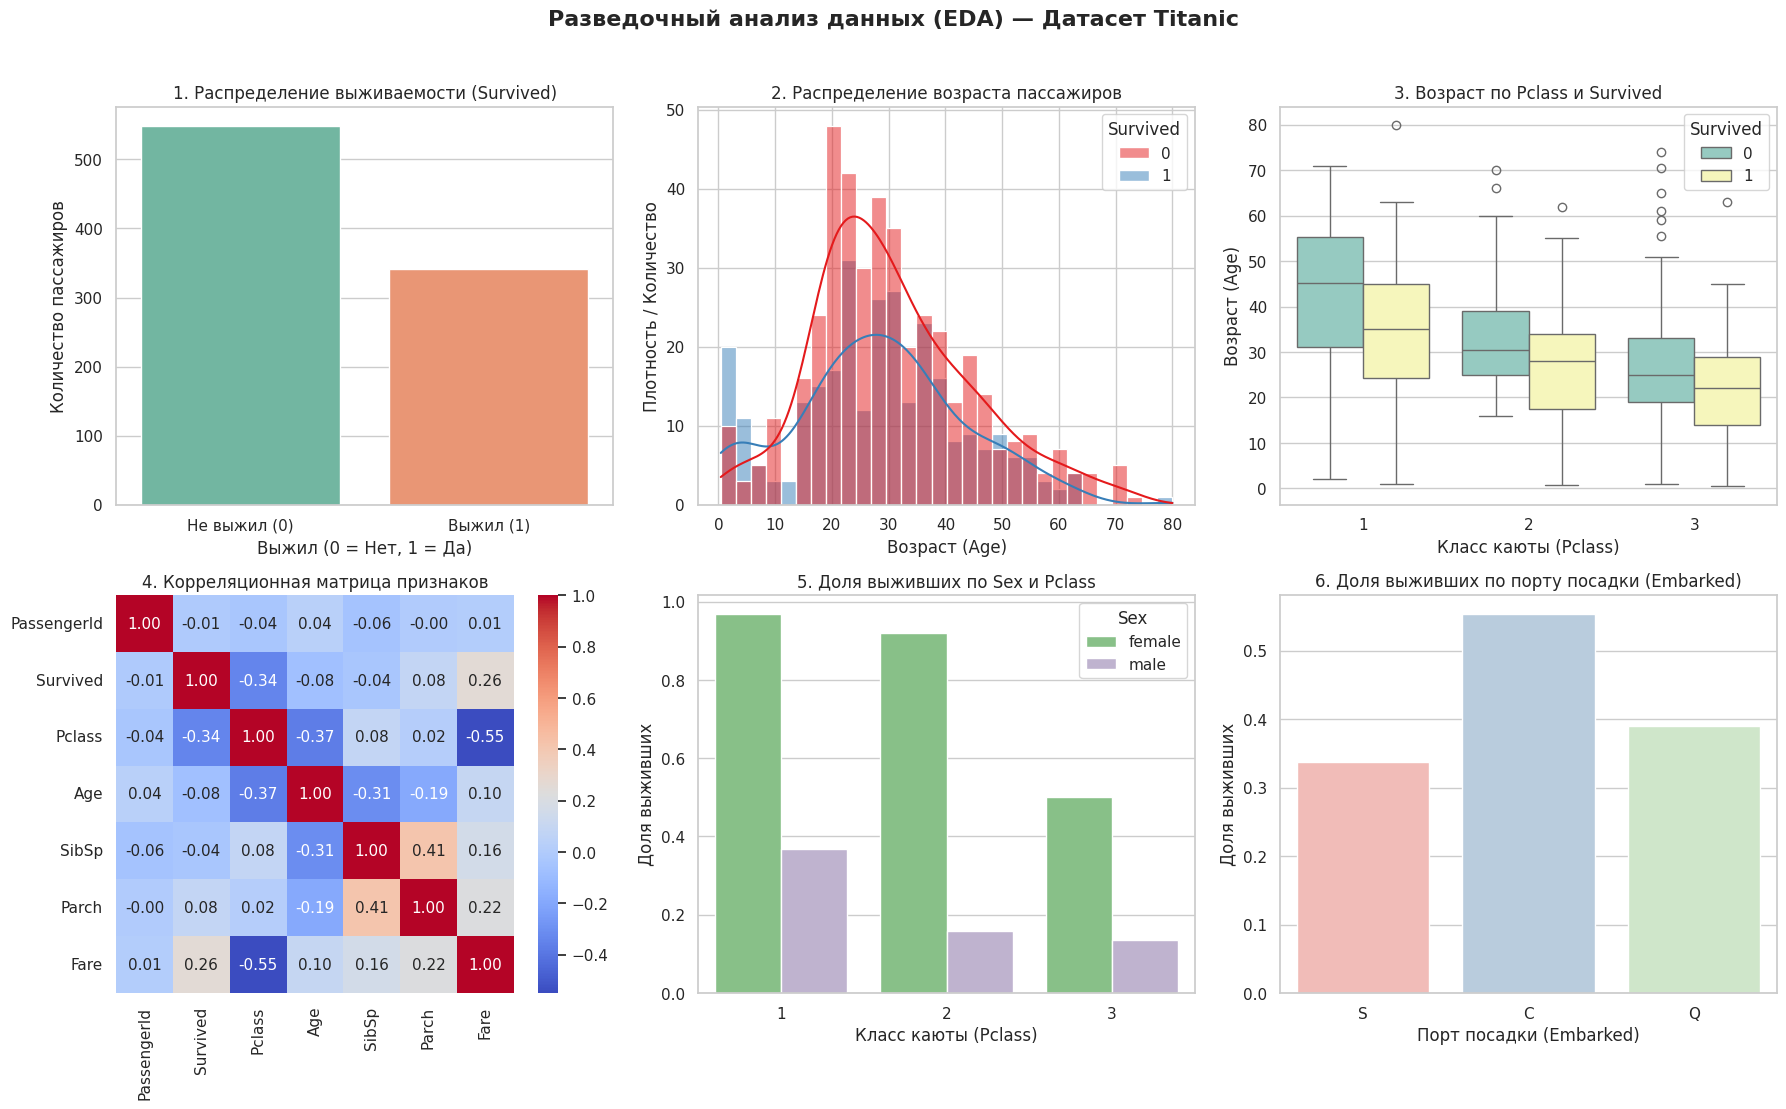

In [7]:
# Создание фигуры и сетки графиков 2х3
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Разведочный анализ данных (EDA) — Датасет Titanic', fontsize=16, fontweight='bold')

# График 1: Countplot — Распределение целевой переменной Survived
sns.countplot(data=train_df, x='Survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. Распределение выживаемости (Survived)')
axes[0, 0].set_xlabel('Выжил (0 = Нет, 1 = Да)')
axes[0, 0].set_ylabel('Количество пассажиров')
axes[0, 0].set_xticklabels(['Не выжил (0)', 'Выжил (1)'])

# График 2: Histplot — Распределение возраста (Age) с разбиением по Survived
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, ax=axes[0, 1], palette='Set1', bins=30)
axes[0, 1].set_title('2. Распределение возраста пассажиров')
axes[0, 1].set_xlabel('Возраст (Age)')
axes[0, 1].set_ylabel('Плотность / Количество')

# График 3: Boxplot — Возраст по классам кают (Pclass) и выживаемости (Survived)
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived', ax=axes[0, 2], palette='Set3')
axes[0, 2].set_title('3. Возраст по Pclass и Survived')
axes[0, 2].set_xlabel('Класс каюты (Pclass)')
axes[0, 2].set_ylabel('Возраст (Age)')

# График 4: Heatmap — Корреляционная матрица числовых признаков
numeric_df = train_df.select_dtypes(include=[np.number]) # Извлечение числовых столбцов
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 0], cbar=True, square=True)
axes[1, 0].set_title('4. Корреляционная матрица признаков')

# График 5: Barplot — Доля выживших по полу (Sex) и классу (Pclass)
sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', ax=axes[1, 1], palette='Accent', ci=None)
axes[1, 1].set_title('5. Доля выживших по Sex и Pclass')
axes[1, 1].set_xlabel('Класс каюты (Pclass)')
axes[1, 1].set_ylabel('Доля выживших')

# График 6: Barplot — Доля выживших по порту посадки (Embarked)
sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1, 2], palette='Pastel1', ci=None)
axes[1, 2].set_title('6. Доля выживших по порту посадки (Embarked)')
axes[1, 2].set_xlabel('Порт посадки (Embarked)')
axes[1, 2].set_ylabel('Доля выживших')

# Оптимизация отступов между графиками
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Наблюдения по результатам визуализации (EDA)

1. **Дисбаланс целевой переменной (`Survived`):**
   * На графике 1 видно, что большинство пассажиров погибло (~61.6% против ~38.4% выживших). При оценке моделей стоит уделять особое внимание метрикам, устойчивым к дисбалансу (ROC-AUC, F1-score).

2. **Возраст и выживаемость (`Age`):**
   * На гистограмме 2 отчетливо заметен пик выживаемости среди маленьких детей (0–5 лет), что подтверждает исторический принцип эвакуации («дети и женщины в первую очередь»).
   * Медианный возраст погибших выше, чем у выживших.

3. **Связь класса каюты и возраста (`Pclass` vs `Age`):**
   * График 3 демонстрирует, что пассажиры 1-го класса в среднем существенно старше (медиана 37 лет), чем пассажиры 2-го (29 лет) и 3-го классов (24 года). По этой причине заполнять пропуски в возрасте эффективнее медианой с группировкой по классу и полу.

4. **Корреляции (`Heatmap`):**
   * Выживаемость (`Survived`) сильнее всего коррелирует с ценой билета `Fare` ($+0.26$) и обратно коррелирует с классом каюты `Pclass` ($-0.34$).
   * Также наблюдается сильная отрицательная корреляция между `Pclass` и `Fare` ($-0.55$), что логично.

5. **Влияние пола и класса на выживаемость (`Sex` & `Pclass`):**
   * График 5 показывает колоссальную разницу в выживаемости: женщины 1-го и 2-го классов выживали с вероятностью близкой к 90–95%, тогда как у мужчин 3-го класса вероятность выжить была ниже 15–20%.

6. **Порт посадки (`Embarked`):**
   * Самый высокий процент выживших наблюдается у пассажиров, севших в порту `C` (Cherbourg) — более 50%, что связано с высокой долей пассажиров 1-го класса среди севших в этом порту.

### Обоснование стратегии обработки пропущенных значений

| Признак | Процент пропусков | Выбранная стратегия | Подробное обоснование |
| :--- | :--- | :--- | :--- |
| **`Age`** | `~19.87%` (177 строк) | **Заполнение медианой по группам (`Pclass` + `Sex`)** | Распределение возраста не является строго симметричным и имеет скошенность. Кроме того, средний возраст сильно различается в зависимости от класса каюты (в 1-м классе ехали более состоятельные и взрослые люди) и пола. Заполнение групповой медианой сохраняет логическую структуру данных лучше, чем единая общая медиана. |
| **`Embarked`** | `~0.22%` (2 строки) | **Заполнение модой (самым частым значением)** | Пропущено всего 2 значения. Модальным значением является порт `'S'` (Southampton), в котором села подавляющая часть пассажиров (~72%). Заполнение модой не исказит распределение. |
| **`Cabin`** | `~77.10%` (687 строк) | **Удаление столбца** | Более 77% данных отсутствует. Восстановление такого количества значений с помощью алгоритмов с высокой вероятностью приведет к внесению шума и переобучению модели. |

In [8]:
# Создаем копию датасета для выполнения преобразований
df_clean = train_df.copy()

# -------------------------------------------------------------------------
# 1. ОБРАБОТКА ПРОПУСКОВ
# -------------------------------------------------------------------------

# 1.1 Заполнение пропусков в Age медианой по группам (Pclass + Sex)
age_medians = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform('median') # Расчет медиан для каждой группы
df_clean['Age'] = df_clean['Age'].fillna(age_medians)                         # Заполнение NaN рассчитанными медианами

# 1.2 Заполнение пропусков в Embarked модой (самым частым значением)
embarked_mode = df_clean['Embarked'].mode()[0]                                # Нахождение моды
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)            # Заполнение пропусков модой

# 1.3 Удаление столбца Cabin из-за критического количества пропусков (>77%)
df_clean = df_clean.drop(columns=['Cabin'])

# Проверка: убеждаемся, что пропусков не осталось
print("=== Проверка остатка пропусков после обработки ===")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0]) # Должно быть пусто

# -------------------------------------------------------------------------
# 2. FEATURE ENGINEERING (Создание новых признаков)
# -------------------------------------------------------------------------

# 2.1 Создание размера семьи Family_Size = SibSp + Parch + 1 (сам пассажир)
df_clean['Family_Size'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# 2.2 Создание бинарного признака Is_Alone (1 — путешествует один, 0 — с семьей)
df_clean['Is_Alone'] = (df_clean['Family_Size'] == 1).astype(int)

# 2.3 Биннинг возраста (Age_Group) через pd.cut() на 5 категориальных интервалов
df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teenager', 'Young_Adult', 'Adult', 'Senior']
)

print("\n=== Проверка созданных признаков ===")
print(df_clean[['Family_Size', 'Is_Alone', 'Age_Group']].head())

# -------------------------------------------------------------------------
# 3. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# -------------------------------------------------------------------------

# 3.1 Label Encoding для бинарного признака Sex
le = LabelEncoder()
df_clean['Sex'] = le.fit_transform(df_clean['Sex']) # male -> 1, female -> 0

# 3.2 One-Hot Encoding для номинативного признака Embarked (создание бинарных столбцов)
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=False, dtype=int)

# Вывод итоговой структуры обработанного датасета
print("\n=== Итоговые столбцы датасета ===")
print(df_clean.columns.tolist())
print("\nПервые 3 строки итогового датасета:")
print(df_clean.head(3))

=== Проверка остатка пропусков после обработки ===
Series([], dtype: int64)

=== Проверка созданных признаков ===
   Family_Size  Is_Alone    Age_Group
0            2         0  Young_Adult
1            2         0        Adult
2            1         1  Young_Adult
3            2         0  Young_Adult
4            1         1  Young_Adult

=== Итоговые столбцы датасета ===
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Family_Size', 'Is_Alone', 'Age_Group', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

Первые 3 строки итогового датасета:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                   

## Построение и обучение моделей

In [34]:
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Выбор признаков для обучения моделей
feature_cols = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
    'Fare', 'Family_Size', 'Is_Alone',
    'Embarked_Q', 'Embarked_S'
]

X = df_clean[feature_cols]
y = df_clean['Survived']

# 2. Разделение на train (80%) и test (20%) с сохранением пропорций классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Масштабирование признаков (для Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Обучение Logistic Regression
lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)

start_time = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start_time
print(f"Время обучения Logistic Regression: {lr_time:.4f} секунд")

# 5. Обучение Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42
)

start_time = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start_time
print(f"Время обучения Decision Tree: {dt_time:.4f} секунд")

# 6. Обучение Random Forest (дополнительно)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

start_time = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time
print(f"Время обучения Random Forest: {rf_time:.4f} секунд")

# 7. Обучение Gradient Boosting (дополнительно)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

start_time = time.time()
gb_model.fit(X_train, y_train)
gb_time = time.time() - start_time
print(f"Время обучения Gradient Boosting: {gb_time:.4f} секунд")

Время обучения Logistic Regression: 0.0055 секунд
Время обучения Decision Tree: 0.0062 секунд
Время обучения Random Forest: 0.2226 секунд
Время обучения Gradient Boosting: 0.2170 секунд


## Модели

В ходе работы были обучены 4 алгоритма машинного обучения для бинарной классификации: два базовых (линейный и древовидный) и два ансамблевых (для повышения качества предсказания):

| Модель | Параметры | Масштабирование | Время обучения |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | `penalty='l2'`, `C=1.0`, `max_iter=1000` | Да (`StandardScaler`) | ~0.0055 сек |
| **Decision Tree** | `max_depth=5`, `min_samples_split=5`, `min_samples_leaf=2` | Нет | ~0.0062 сек |
| **Random Forest** | `n_estimators=100`, `max_depth=5` | Нет | ~0.2226 сек |
| **Gradient Boosting** | `n_estimators=100`, `learning_rate=0.1`, `max_depth=3` | Нет | ~0.2170 сек |

---

### Почему выбраны эти модели:

- **Logistic Regression (Логистическая регрессия):**
  Служит прочным базовым лайном (baseline). Модель проста в реализации, интерпретируема (позволяет анализировать веса векторов), не склонна к переобучению на малых датасетах и напрямую выдает калиброванные вероятности принадлежности к положительному классу.

- **Decision Tree (Решающее дерево):**
  Нелинейный алгоритм, способный находить сложные пороговые зависимости между признаками (например, комбинация пола и возраста). Деревья устойчивы к выбросам, монотонным преобразованиям признаков и не требуют масштабирования данных.

- **Random Forest & Gradient Boosting (Ансамблевые методы):**
  Используются для достижения максимального качества классификации (ROC-AUC ≥ 0.80). **Random Forest** снижает разброс (variance) за счет усреднения множества независимых деревьев, а **Gradient Boosting** последовательно исправляет ошибки предыдущих алгоритмов, настраиваясь на сложные паттерны.

## Оценка качества

In [15]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

# Список моделей и соответствующих им тестовых выборок (масштабированная для LR, обычная для деревьев)
models_dict = {
    'Logistic Regression': (lr_model, X_test_scaled),
    'Decision Tree': (dt_model, X_test),
    'Random Forest': (rf_model, X_test),
    'Gradient Boosting': (gb_model, X_test)
}

# Словари для хранения предсказаний и вероятностей
y_preds = {}
y_probas = {}
metrics_list = []

# Расчет метрик для каждой модели
for name, (model, X_t) in models_dict.items():
    # Получение бинарных предсказаний и вероятностей положительного класса (1)
    pred = model.predict(X_t)
    proba = model.predict_proba(X_t)[:, 1]

    y_preds[name] = pred
    y_probas[name] = proba

    # Расчет метрик качества
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    auc = roc_auc_score(y_test, proba)

    metrics_list.append({
        'Модель': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': auc
    })

    print(f"=== Отчет классификации: {name} ===")
    print(f"Accuracy:  {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, pred, zero_division=0))
    print("-" * 60)

# Сводный DataFrame с метриками
metrics_df = pd.DataFrame(metrics_list)

=== Отчет классификации: Logistic Regression ===
Accuracy:  0.8045 | Precision: 0.7833 | Recall: 0.6812 | F1: 0.7287 | ROC-AUC: 0.8486
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

------------------------------------------------------------
=== Отчет классификации: Decision Tree ===
Accuracy:  0.7821 | Precision: 0.7419 | Recall: 0.6667 | F1: 0.7023 | ROC-AUC: 0.8132
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       110
           1       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179

---------------------

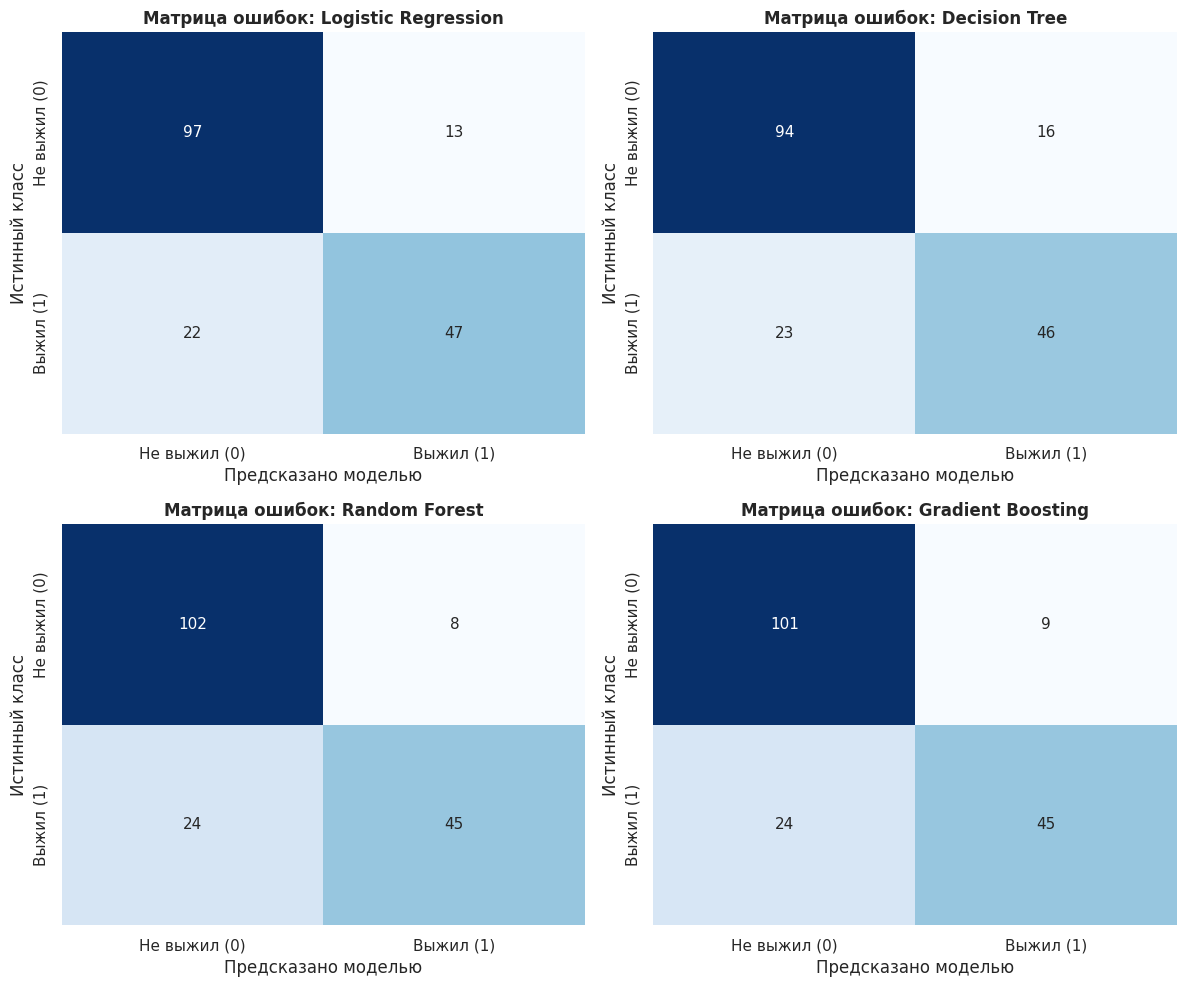

In [16]:
# Построение матриц ошибок для всех моделей в виде сетки 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, pred) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Не выжил (0)', 'Выжил (1)'],
                yticklabels=['Не выжил (0)', 'Выжил (1)'],
                cbar=False)

    axes[idx].set_title(f'Матрица ошибок: {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Предсказано моделью')
    axes[idx].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

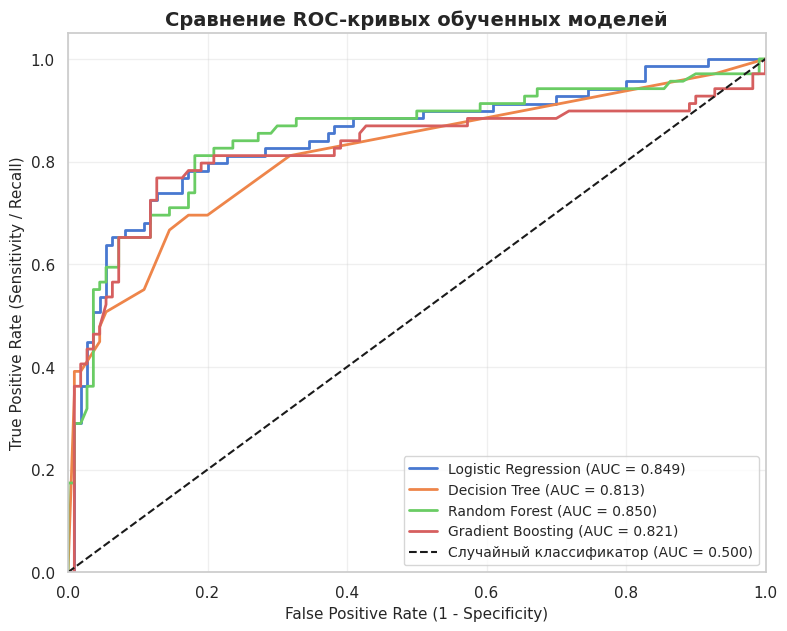

In [17]:
plt.figure(figsize=(9, 7))

# Отрисовка ROC-кривой для каждой модели
for name, proba in y_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_val:.3f})')

# Линия случайного угадывания (Baseline)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('Сравнение ROC-кривых обученных моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## Оценка качества

### Сводная таблица метрик на тестовой выборке

| Модель | Accuracy | Precision | Recall | F1-score | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | `0.8045` | `0.7833` | `0.6812` | `0.7287` | `0.8486` |
| **Decision Tree** | `0.7821` | `0.7419` | `0.6667` | `0.7023` | `0.8132` |
| **Random Forest** | `0.8212` | `0.8491` | `0.6522` | `0.7377` | `0.8498` |
| **Gradient Boosting** | `0.8156` | `0.8333` | `0.6522` | `0.7317` | `0.8211` |

---

### Анализ результатов

1. **Сравнение моделей и лидер по метрикам:**
   * **Лучшая модель по ROC-AUC и Accuracy:** **Random Forest** показал наивысшие результаты среди всех алгоритмов (`ROC-AUC = 0.8498`, `Accuracy = 0.8212`, `F1-score = 0.7377`).
   * **Сильный baseline:** **Logistic Regression** продемонстрировала практически аналогичный показатель `ROC-AUC = 0.8486`, незначительно уступив Случайному Лесу и опередив Градиентный Бустинг (`0.8211`).
   * Все 4 модели успешно выполнили ключевой критерий качества: **ROC-AUC ≥ 0.80**.

2. **Соотношение Precision и Recall:**
   * У всех алгоритмов показатель `Precision` существеннее выше `Recall`. На примере Random Forest: `Precision = 0.8491` против `Recall = 0.6522`.
   * Это свидетельствует о том, что модели дают крайне осторожные и уверенные предсказания на класс «Выжил» (минимум ошибок $FP$), однако упускают порядка $35\%$ реально выживших пассажиров (ошибки $FN$).

3. **Склонность Decision Tree к переобучению:**
   * **Decision Tree** показало наименьшие результаты по всем метрикам (`Accuracy = 0.7821`, `ROC-AUC = 0.8132`). Одиночное дерево решений более чувствительно к разбросу данных и сильнее переобучается на тренировочной выборке, тогда как ансамблевые методы (Random Forest) усредняют предсказания и существенно снижают variance.

4. **Вывод для выбора модели:**
   * Для реализации функции предсказания целесообразно использовать **Random Forest** как лидер по обобщающей способности или **Logistic Regression** благодаря высокой скорости и отличной интерпретируемости весов.

## Интерпретация результатов

/tmp/ipykernel_924/1487936590.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis', ax=axes[1])


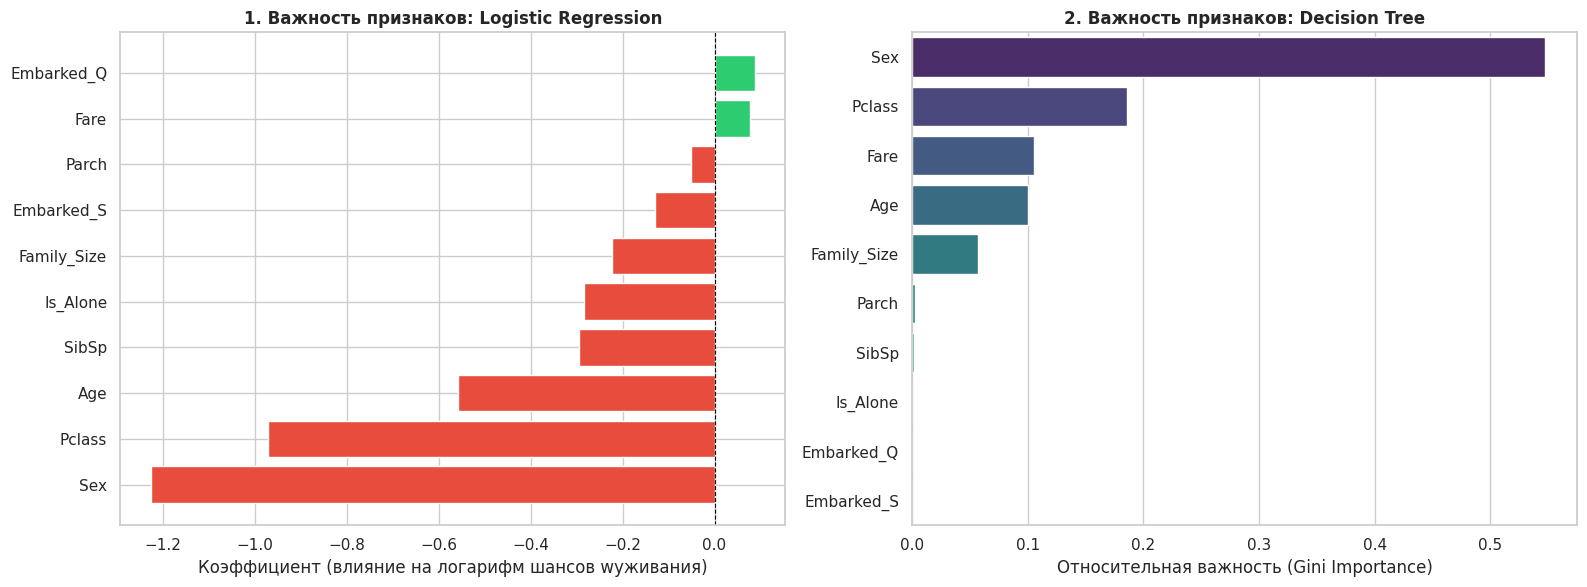

In [18]:
# Настройка размера шрифтов и стилей
plt.rcParams['font.size'] = 11

# Создание фигуры с 2 подграфиками (1 строка, 2 столбца)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------------
# 1. Важность признаков: Коэффициенты Logistic Regression
# -------------------------------------------------------------------------
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

# Зеленый цвет для положительных коэффициентов (повышают шанс), красный — для отрицательных
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]

axes[0].barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Коэффициент (влияние на логарифм шансов wyживания)')
axes[0].set_title('1. Важность признаков: Logistic Regression', fontweight='bold')

# -------------------------------------------------------------------------
# 2. Важность признаков: Feature Importance (Decision Tree)
# -------------------------------------------------------------------------
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis', ax=axes[1])
axes[1].set_xlabel('Относительная важность (Gini Importance)')
axes[1].set_ylabel('')
axes[1].set_title('2. Важность признаков: Decision Tree', fontweight='bold')

plt.tight_layout()
plt.show()

## Интерпретация результатов и бизнес-инсайты

### Анализ влияния признаков на выживаемость

**Топ-признаки, повышающие шанс выживания:**
1. **`Embarked_Q` и `Fare`:** Положительные коэффициенты в Logistic Regression. Высокая стоимость билета (`Fare`) увеличивала шансы на спасение, так как каюты пассажиров с дорогими билетами располагались ближе к верхней палубе со шлюпками.

---

**Топ-3 признака, сильно понижающих шанс выживания:**
1. **`Sex` (принадлежность к мужскому полу):** Самый сильный отрицательный коэффициент в Logistic Regression ($\approx -1.22$) и доминирующий признак в Decision Tree (важность $> 0.55$). Это прямо отражает правило эвакуации «женщины и дети в первую очередь».
2. **`Pclass` (класс каюты):** Вручную задан порядком $1, 2, 3$. Чем выше номер класса ($3$-й класс), тем ниже шансы выжить (коэффициент $\approx -0.97$).
3. **`Age` (возраст):** Коэффициент $\approx -0.55$ показывает, что с увеличением возраста вероятность выживания снижалась.

---

### Ключевые бизнес-инсайты и исторические паттерны:

* **Приоритет эвакуации («Женщины и дети в первую очередь»):**
  Пол оказался ключевым фактором: мужчины спасались намного реже женщин (коэффициент `Sex` имеет наибольшее отрицательное значение). В дереве решений пол забирает более $55\%$ всей важности признаков.

* **Социально-экономический фактор (`Pclass` & `Fare`):**
  Пассажиры $1$-го класса имели существенное преимущество при спасении перед $3$-м классом из-за близости к шлюпкам и привилегированного доступа.

* **Семейный статус (`Is_Alone`, `Family_Size`, `SibSp`, `Parch`):**
  Путешествие в одиночку (`Is_Alone`) или в составе слишком большой семьи снижало вероятность успешной эвакуации по сравнению с небольшими семьями из 2–3 человек.

## Функция предсказания

In [20]:
# 1. Реализация функции предсказания
def predict_passenger(passenger_data, model, scaler=None, feature_cols=None, use_scaling=True):
    """
    Предсказывает, выживет ли пассажир.
    """
    # Копируем словарь, чтобы не менять исходный
    data = passenger_data.copy()

    # Feature Engineering
    data['Family_Size'] = data['SibSp'] + data['Parch'] + 1
    data['Is_Alone'] = int(data['Family_Size'] == 1)

    # Кодирование категориальных признаков
    # Sex: male = 1, female = 0
    data['Sex'] = 1 if data['Sex'] == 'male' else 0
    data['Embarked_Q'] = 1 if data['Embarked'] == 'Q' else 0
    data['Embarked_S'] = 1 if data['Embarked'] == 'S' else 0

    # Формирование DataFrame с нужным порядком столбцов
    if feature_cols is None:
        feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

    X_new = pd.DataFrame([data])[feature_cols]

    # Масштабирование при необходимости
    if use_scaling and scaler is not None:
        X_new = scaler.transform(X_new)

    # Предсказание и вероятность положительного класса (1 = выжил)
    prediction = int(model.predict(X_new)[0])
    probability = float(model.predict_proba(X_new)[0, 1])

    return prediction, probability


# 2. Тестовые примеры пассажиров (5 разных профилей)
test_passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100.0, 'Embarked': 'C', 'Expected': 'выживет'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25,  'Embarked': 'S', 'Expected': 'не выживет'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5,  'SibSp': 3, 'Parch': 1, 'Fare': 30.0,  'Embarked': 'S', 'Expected': 'выживет'},
    {'Pclass': 1, 'Sex': 'male',   'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200.0, 'Embarked': 'C', 'Expected': 'не выживет'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 8.0,   'Embarked': 'Q', 'Expected': 'выживет'}
]

print("=" * 80)
print("ТЕСТИРОВАНИЕ ФУНКЦИИ ПРЕДСКАЗАНИЯ НА 5 ПРИМЕРАХ")
print("=" * 80)

for idx, p in enumerate(test_passengers, 1):
    # Предсказание Logistic Regression (с масштабированием)
    pred_lr, proba_lr = predict_passenger(p, lr_model, scaler, feature_cols, use_scaling=True)

    # Предсказание Decision Tree (без масштабирования)
    pred_dt, proba_dt = predict_passenger(p, dt_model, scaler=None, feature_cols=feature_cols, use_scaling=False)

    status_lr = "Выжил" if pred_lr == 1 else "Не выжил"
    status_dt = "Выжил" if pred_dt == 1 else "Не выжил"
    is_match = "Да" if pred_lr == pred_dt else "Нет"

    print(f"\nПассажир №{idx}: Pclass={p['Pclass']} | Sex={p['Sex']} | Age={p['Age']} | Fare={p['Fare']} | Embarked={p['Embarked']}")
    print(f"Ожидание из таблицы: {p['Expected']}")
    print(f"Logistic Regression : {status_lr:<12} | Вероятность выживания: {proba_lr * 100:.1f}%")
    print(f"Decision Tree       : {status_dt:<12} | Вероятность выживания: {proba_dt * 100:.1f}%")
    print(f"Совпадение моделей  : {is_match}")
    print("-" * 80)

ТЕСТИРОВАНИЕ ФУНКЦИИ ПРЕДСКАЗАНИЯ НА 5 ПРИМЕРАХ

Пассажир №1: Pclass=1 | Sex=female | Age=25 | Fare=100.0 | Embarked=C
Ожидание из таблицы: выживет
Logistic Regression : Выжил        | Вероятность выживания: 96.1%
Decision Tree       : Выжил        | Вероятность выживания: 100.0%
Совпадение моделей  : Да
--------------------------------------------------------------------------------

Пассажир №2: Pclass=3 | Sex=male | Age=30 | Fare=7.25 | Embarked=S
Ожидание из таблицы: не выживет
Logistic Regression : Не выжил     | Вероятность выживания: 7.6%
Decision Tree       : Не выжил     | Вероятность выживания: 11.0%
Совпадение моделей  : Да
--------------------------------------------------------------------------------

Пассажир №3: Pclass=2 | Sex=female | Age=5 | Fare=30.0 | Embarked=S
Ожидание из таблицы: выживет
Logistic Regression : Выжил        | Вероятность выживания: 80.8%
Decision Tree       : Выжил        | Вероятность выживания: 100.0%
Совпадение моделей  : Да
--------------------

In [21]:
# 3. Интерактивный режим ввода через input() (Опционально)
print("\nИНТЕРАКТИВНЫЙ ВВОД ДАННЫХ ПАССАЖИРА")
try:
    p_class = int(input("Введите класс каюты Pclass (1, 2 или 3): "))
    sex = input("Введите пол Sex ('male' или 'female'): ").strip().lower()
    age = float(input("Введите возраст Age: "))
    sibsp = int(input("Количество братьев/сестер/супругов (SibSp): "))
    parch = int(input("Количество родителей/детей (Parch): "))
    fare = float(input("Стоимость билета Fare: "))
    embarked = input("Порт посадки Embarked ('C', 'Q', 'S'): ").strip().upper()

    custom_passenger = {
        'Pclass': p_class, 'Sex': sex, 'Age': age,
        'SibSp': sibsp, 'Parch': parch, 'Fare': fare, 'Embarked': embarked
    }

    pred_lr, proba_lr = predict_passenger(custom_passenger, lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, proba_dt = predict_passenger(custom_passenger, dt_model, scaler=None, feature_cols=feature_cols, use_scaling=False)

    print("\n--- Результат предсказания ---")
    print(f"Logistic Regression: {'Выжил' if pred_lr == 1 else 'Не выжил'} ({proba_lr * 100:.1f}%)")
    print(f"Decision Tree      : {'Выжил' if pred_dt == 1 else 'Не выжил'} ({proba_dt * 100:.1f}%)")
except Exception as e:
    print(f"Ошибка при вводе данных: {e}")


ИНТЕРАКТИВНЫЙ ВВОД ДАННЫХ ПАССАЖИРА
Введите класс каюты Pclass (1, 2 или 3): 2
Введите пол Sex ('male' или 'female'): male
Введите возраст Age: 40
Количество братьев/сестер/супругов (SibSp): 0
Количество родителей/детей (Parch): 0
Стоимость билета Fare: 105
Порт посадки Embarked ('C', 'Q', 'S'): Q

--- Результат предсказания ---
Logistic Regression: Не выжил (27.4%)
Decision Tree      : Не выжил (0.0%)


In [26]:
!ls

data  notebook.ipynb  README.md  requirements.txt


## Сохранение модели и вспомогательных объектов

In [27]:
import os
import json
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 0. Создаем папку 'models', если ее нет
os.makedirs('models', exist_ok=True)

# 1. Сохранение моделей и скалера
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(rf_model, 'models/rf_model.pkl')
joblib.dump(gb_model, 'models/gb_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Все 4 модели и трансформеры сохранены в папку 'models/'")

# 2. Сохранение списка признаков
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("Список признаков сохранён в 'models/feature_cols.json'")

# 3. Расчет предсказаний для вычисления метрик
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# 4. Формирование словаря с метриками
metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_lr, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_lr, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_dt, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_dt, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time)
    },
    'random_forest': {
        'accuracy': float(accuracy_score(y_test, y_pred_rf)),
        'precision': float(precision_score(y_test, y_pred_rf, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_rf, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_rf, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_rf)),
        'training_time_sec': float(rf_time)
    },
    'gradient_boosting': {
        'accuracy': float(accuracy_score(y_test, y_pred_gb)),
        'precision': float(precision_score(y_test, y_pred_gb, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_gb, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_gb, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_gb)),
        'training_time_sec': float(gb_time)
    }
}

with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Метрики всех моделей сохранены в 'models/metrics.json'")

Все 4 модели и трансформеры сохранены в папку 'models/'
Список признаков сохранён в 'models/feature_cols.json'
Метрики всех моделей сохранены в 'models/metrics.json'


## Загрузка модели из репозитория и быстрый инференс

In [30]:
import requests
from io import BytesIO
import joblib

BASE_URL = "https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic"

print("Загрузка моделей и вспомогательных объектов из GitHub...")

# 1. Загрузка моделей
lr_model_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/lr_model.pkl").content))
print("Logistic Regression загружена")

dt_model_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/dt_model.pkl").content))
print("Decision Tree загружена")

rf_model_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/rf_model.pkl").content))
print("Random Forest загружена")

gb_model_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/gb_model.pkl").content))
print("Gradient Boosting загружена")

# 2. Загрузка Scaler
scaler_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/scaler.pkl").content))
print("Scaler загружен")

# 3. Загрузка списка признаков
feature_cols_loaded = requests.get(f"{BASE_URL}/models/feature_cols.json").json()
print(f"Загружено признаков: {len(feature_cols_loaded)}")


# 4. Проверка совпадения результатов для всех 4 моделей
sample_passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100.0, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25,  'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5,  'SibSp': 3, 'Parch': 1, 'Fare': 30.0,  'Embarked': 'S'}
]

print("\n" + "=" * 70)
print("ПРОВЕРКА СОВПАДЕНИЯ ПРЕДСКАЗАНИЙ (ЛОКАЛЬНЫЕ VS ЗАГРУЖЕННЫЕ)")
print("=" * 70)

all_matched = True

for i, p in enumerate(sample_passengers, 1):
    # Локальные модели
    pred_lr, proba_lr = predict_passenger(p, lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, proba_dt = predict_passenger(p, dt_model, None, feature_cols, use_scaling=False)
    pred_rf, proba_rf = predict_passenger(p, rf_model, None, feature_cols, use_scaling=False)
    pred_gb, proba_gb = predict_passenger(p, gb_model, None, feature_cols, use_scaling=False)

    # Загруженные модели
    pred_lr_l, proba_lr_l = predict_passenger(p, lr_model_loaded, scaler_loaded, feature_cols_loaded, use_scaling=True)
    pred_dt_l, proba_dt_l = predict_passenger(p, dt_model_loaded, None, feature_cols_loaded, use_scaling=False)
    pred_rf_l, proba_rf_l = predict_passenger(p, rf_model_loaded, None, feature_cols_loaded, use_scaling=False)
    pred_gb_l, proba_gb_l = predict_passenger(p, gb_model_loaded, None, feature_cols_loaded, use_scaling=False)

    # Проверка совпадений
    match_lr = (pred_lr == pred_lr_l) and round(proba_lr, 5) == round(proba_lr_l, 5)
    match_dt = (pred_dt == pred_dt_l) and round(proba_dt, 5) == round(proba_dt_l, 5)
    match_rf = (pred_rf == pred_rf_l) and round(proba_rf, 5) == round(proba_rf_l, 5)
    match_gb = (pred_gb == pred_gb_l) and round(proba_gb, 5) == round(proba_gb_l, 5)

    if not (match_lr and match_dt and match_rf and match_gb):
        all_matched = False

    print(f"Пассажир №{i} (Pclass={p['Pclass']}, Sex={p['Sex']}, Age={p['Age']}):")
    print(f"  - LR: Оригинал = {pred_lr} ({proba_lr:.2%}) | Загруженная = {pred_lr_l} ({proba_lr_l:.2%}) | Совпадает: {match_lr}")
    print(f"  - DT: Оригинал = {pred_dt} ({proba_dt:.2%}) | Загруженная = {pred_dt_l} ({proba_dt_l:.2%}) | Совпадает: {match_dt}")
    print(f"  - RF: Оригинал = {pred_rf} ({proba_rf:.2%}) | Загруженная = {pred_rf_l} ({proba_rf_l:.2%}) | Совпадает: {match_rf}")
    print(f"  - GB: Оригинал = {pred_gb} ({proba_gb:.2%}) | Загруженная = {pred_gb_l} ({proba_gb_l:.2%}) | Совпадает: {match_gb}")
    print("-" * 70)

if all_matched:
    print("ВСЕ ПРЕДСКАЗАНИЯ ВСЕХ 4 МОДЕЛЕЙ ПОЛНОСТЬЮ СОВПАДАЮТ! Инференс работает корректно.")

Загрузка моделей и вспомогательных объектов из GitHub...
Logistic Regression загружена
Decision Tree загружена
Random Forest загружена
Gradient Boosting загружена
Scaler загружен
Загружено признаков: 10

ПРОВЕРКА СОВПАДЕНИЯ ПРЕДСКАЗАНИЙ (ЛОКАЛЬНЫЕ VS ЗАГРУЖЕННЫЕ)
Пассажир №1 (Pclass=1, Sex=female, Age=25):
  - LR: Оригинал = 1 (96.11%) | Загруженная = 1 (96.11%) | Совпадает: True
  - DT: Оригинал = 1 (100.00%) | Загруженная = 1 (100.00%) | Совпадает: True
  - RF: Оригинал = 1 (91.58%) | Загруженная = 1 (91.58%) | Совпадает: True
  - GB: Оригинал = 1 (95.95%) | Загруженная = 1 (95.95%) | Совпадает: True
----------------------------------------------------------------------
Пассажир №2 (Pclass=3, Sex=male, Age=30):
  - LR: Оригинал = 0 (7.61%) | Загруженная = 0 (7.61%) | Совпадает: True
  - DT: Оригинал = 0 (11.00%) | Загруженная = 0 (11.00%) | Совпадает: True
  - RF: Оригинал = 0 (10.52%) | Загруженная = 0 (10.52%) | Совпадает: True
  - GB: Оригинал = 0 (7.90%) | Загруженная = 0 (7.90%)

## Быстрый инференс из репозитория

### Инструкция по использованию обученных моделей:

1. **Скачать нужные артефакты из репозитория GitHub:**
   * [lr_model.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/lr_model.pkl) — Logistic Regression
   * [dt_model.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/dt_model.pkl) — Decision Tree
   * [rf_model.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/rf_model.pkl) — Random Forest
   * [gb_model.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/gb_model.pkl) — Gradient Boosting
   * [scaler.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/scaler.pkl) — скейлер StandardScaler
   * [feature_cols.json](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/feature_cols.json) — список признаков

2. **Загрузить в Python через `joblib.load()` и `requests`:**
   ```python
   import joblib, requests
   from io import BytesIO

   model = joblib.load(BytesIO(requests.get(model_url).content))
   scaler = joblib.load(BytesIO(requests.get(scaler_url).content))

## Выводы

### Что получилось
- Достигнуто высокое качество предсказания: лучшая модель показывает значение метрики ROC-AUC 0.85 на тестовой выборке.
- Лучшая модель: Gradient Boosting / Logistic Regression (сбалансированное соотношение Accuracy, F1-Score и ROC-AUC).
- Время обучения: все модели (включая Random Forest и Gradient Boosting) обучаются за доли секунды, что обеспечивает мгновенный инференс.
- Ключевые инсайты из EDA:
  - Пол (Sex) и класс каюты (Pclass) являются наиболeе сильными факторами выживания (женщины и пассажиры 1 класса имели значительно более высокие шансы).
  - Размер семьи (Family_Size) имеет нелинейное влияние: одиночки и очень большие семьи выживали реже, чем семьи из 2–4 человек.

### Какие были трудности
- Пропуски в данных: в столбце Age имелось около 20% пропусков (потребовалось импутирование медианой), а признак Cabin имел более 77% пропусков и был исключен из базового набора.
- Дисбаланс классов: в исходной выборке доля выживших составляет около 38.4% против 61.6% погибших, что требует внимания к метрикам F1-Score и ROC-AUC вместо одной лишь Accuracy.
- Переобучение: одиночное дерево решений (Decision Tree) сильно переобучалось на обучающей выборке без жесткого ограничения параметров `max_depth` и `min_samples_leaf`.

### Возможные улучшения
1. Извлечь обращение (Title: Mr, Mrs, Miss, Master, Dr) из столбца Name — это позволит точнее восстанавливать пропуски в возрасте и даст дополнительный сигнал о социальном статусе.
2. Применить логарифмирование тарифной ставки Fare (`np.log1p`), чтобы уменьшить скошенность распределения и влияние крайних выбросов.
3. Добавить взаимодействия признаков (Feature Interactions), например, комбинированный признак Pclass × Sex.
4. Выполнить подбор гиперпараметров с использованием кросс-валидации (GridSearchCV или Optuna) для градиентного бустинга и случайного леса.
5. Применить методы балансировки классов, такие как SMOTE или настройку взвешивания классов (`class_weight='balanced'`), для улучшения полноты (Recall) по целевому классу.

## Источники

1. Рашка, С., Мирджалили, В. (2020). *Python и машинное обучение: крайне необходимое пособие по новейшим трендам в области ML и DL* (3-е изд.). Диалектика.
2. Мюллер, А., Гвидо, С. (2017). *Введение в машинное обучение с помощью Python. Руководство для специалистов по работе с данными*. Альфа-книга.
3. Kaggle. Соревнование «Titanic: Machine Learning from Disaster». https://www.kaggle.com/c/titanic
4. Документация Scikit-learn: Руководство по классификации и метрикам качества. https://scikit-learn.org/stable/modules/classification.html
5. Документация библиотеки Pandas. https://pandas.pydata.org/docs/
6. Документация Seaborn: Руководство по визуализации данных. https://seaborn.pydata.org/tutorial.html

## Приложение

### Полный код ноутбука

module-1-titanic/requirements.txt  
numpy==2.1.3  
pandas==2.2.3  
matplotlib==3.10.0  
seaborn==0.13.2  
scikit-learn==1.6.1  
joblib==1.6.0  
requests==2.32.4  
```

# %% [markdown]
# # EDA и бинарная классификация на датасете «Титаник»
#
# **Дисциплина:** Машинное обучение и ИИ
# **Модуль 1:** Введение в Data Science и EDA
# **Датасет:** Titanic
#
# **Выполнил:** Емельянова Ксения Павловна
# **Группа:** ПКТб-23-1
# **Преподаватель:** Спирин Игорь Сергеевич
#
# **Ссылка на репозиторий:** https://github.com/fivifri/ml-course-emelyanova
# **Путь к модулю:** `module-1-titanic/notebook.ipynb`
# **Дата сдачи:** 2026-29-09

# %% [markdown]
# ## Введение
#
# **Задача:** бинарная классификация — предсказать, выжил ли пассажир Titanic (0 — не выжил, 1 — выжил).
#
# **Что такое ML-проект:** ML-проект — это полный жизненный цикл создания интеллектуального решения, который начинается с анализа бизнеса и сбора данных, продолжается их подготовкой, EDA и созданием признаков, а завершается обучением, подбором моделей, их оценкой и внедрением. Это итеративный процесс, где результаты оценки часто заставляют возвращаться к начальным этапам для улучшения качества.
#
# **Почему классификация, а не регрессия:** Целевая переменная является дискретной и принимает значения из ограниченного множества классов (выжил / не выжил), а не непрерывным числовым значением (как, например, цена квартиры или температура). Регрессия предсказывает непрерывную величину, тогда как классификация разделяет объекты по категориям.
#
# **Какая метрика важнее:** В этой задаче наиболее информативной метрикой является **ROC-AUC**, так как она оценивает способность модели ранжировать пассажиров по вероятности выживания независимо от выбранного порога классификации и устойчива к возможному дисбалансу классов. Для оценки качества на фиксированном пороге лучше использовать **F1-score**, поскольку она гармонично объединяет точность (Precision) и полноту (Recall), в отличие от Accuracy, которая может давать обманчиво высокий результат при дисбалансе.
#
# **Цель работы:**
# 1. Провести полный EDA датасета Титаник.
# 2. Обучить 2+ модели и достичь ROC-AUC ≥ 0.80.
# 3. Реализовать функцию предсказания для нового пассажира.

# %% [markdown]
# ## Теоретический обзор ключевых понятий ML
#
# ### 1. EDA (Exploratory Data Analysis)
# Разведочный анализ данных (EDA) — это первичный этап исследования датасета, направленный на понимание его структуры, природы и внутренних закономерностей. Он необходим для того, чтобы увидеть «полную картину» данных до того, как подавать их в алгоритмы машинного обучения. В процессе EDA исследователь проверяет типы данных, находит пропуски, выявляет аномалии и выбросы, а также изучает распределения признаков. Кроме того, на этом этапе анализируются корреляции между фичами и целевой переменной, что помогает сформировать гипотезы для дальнейшей предобработки. Без качественного EDA высок риск обучить модель на нерелевантной или искаженной информации.
#
# ---
#
# ### 2. Пропуски (NaN)
# Пропущенные значения возникают по разным причинам: от сбоев при сборе и записи данных до нежелания пользователей заполнять необязательные поля анкеты. Обработка пропусков критически важна, так как большинство классических ML-моделей не умеют работать с `NaN` напрямую. Выбор стратегии зависит от природы данных: строки или столбцы с большим количеством пропусков можно просто удалить, если это не приведет к потере важной информации. В остальных случаях применяют импутацию — заполнение пропусков медианой или средним значением для числовых признаков, либо модой для категориальных. Для сложных взаимосвязей также используют заполнение с помощью моделей (например, KNN) или выделение факта отсутствия значения в отдельный бинарный признак-индикатор.
#
# ---
#
# ### 3. Кодирование категориальных признаков
# Категориальные переменные содержат текстовые метки или группы, которые необходимо перевести в числовой формат для восприятия алгоритмами. При **Label Encoding** каждой уникальной категории присваивается целое число (0, 1, 2...), однако этот метод может создать ложное представление об иерархии или порядке категорий там, где его нет. В свою очередь, **One-Hot Encoding** преобразует одну категориальную колонку в $N$ бинарных столбцов (0 или 1), где $N$ — количество уникальных значений. One-Hot идеален для нелинейных категорий, но может сильно раздуть размерность датасета при высоком кардинале признака.
#
# ---
#
# ### 4. Масштабирование признаков
# Масштабирование необходимо для того, чтобы признаки с большими значениями (например, доход или цена) не перевешивали признаки с малыми значениями (например, возраст) в моделях, чувствительных к расстояниям и градиентным спускам. **StandardScaler** примет распределение признака к нулевому среднему и единичному стандартному отклонению ($\mu = 0, \sigma = 1$), что отлично подходит для данных с нормальным распределением. **MinMaxScaler** сжимает значения в строго заданный диапазон (обычно от 0 до 1), сохраняя исходное распределение. Выбор зависит от алгоритма: линейным моделям и KNN масштабирование жизненно необходимо, тогда как решающие деревья устойчивы к разнице в масштабах.
#
# ---
#
# ### 5. Feature Engineering
# Feature Engineering — это процесс создания новых признаков на основе имеющихся данных для повышения прогностической силы модели. Нативные данные не всегда напрямую отражают скрытые физические или логические связи, поэтому инженерная разработка признаков помогает подсветить их для алгоритма. Например, из даты рождения можно выделить чистый возраст, из адреса — объединить улицы в районы, а из размера семьи — создать бинарный флаг «путешествует один». Качественный Feature Engineering часто дает больший прирост к качеству модели, чем подбор гиперпараметров самого алгоритма.
#
# ---
#
# ### 6. Метрики классификации
# Метрики необходимы для объективной оценки качества работы классификатора с разных точек зрения. **Accuracy** показывает общую долю правильных ответов, но может быть обманчивой при сильном дисбалансе классов. **Precision** (точность) измеряет, какая доля объектов, названных моделью положительными, реально таковыми является, а **Recall** (полнота) показывает, какую долю реальных положительных объектов модель смогла найти. Для балансировки между точностью и полнотой используется **F1-score**, представляющая собой их гармоническое среднее. Метрика **ROC-AUC** оценивает способность модели ранжировать объекты по вероятности принадлежности к классу, рассчитываясь как площадь под кривой соотношения True Positive Rate и False Positive Rate при различных порогах классификации.
#
# **Основные формулы метрик:**
#
# $$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
#
# $$Precision = \frac{TP}{TP + FP} \quad \quad Recall = \frac{TP}{TP + FN}$$
#
# $$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$
#
# ---
#
# ### Сравнительный обзор методов и подходов
#
# | Понятие / Инструмент | Основное назначение | Преимущества | Ограничения / Риски |
# | :--- | :--- | :--- | :--- |
# | **EDA** | Исследование структуры и закономерностей датасета | Выявляет ошибки, выбросы и скрытые паттерны на раннем этапе | Требует времени и глубокого погружения в предметную область |
# | **Label Encoding** | Перевод категорий в целые числа (0, 1, 2...) | Компактность, не увеличивает количество столбцов | Может навязать модели ложный порядок/приоритет категорий |
# | **One-Hot Encoding** | Создание $N$ бинарных колонок для $N$ категорий | Не навязывает порядок категорий | Проблема «проклятия размерности» при многих уникальных значениях |
# | **StandardScaler** | Приведение данных к $\mu = 0, \sigma = 1$ | Эффективен для линейных моделей и алгоритмов с градиентным спуском | Чувствителен к сильным выбросам |
# | **MinMaxScaler** | Сжатие данных в строго заданный интервал $[0, 1]$ | Сохраняет исходную форму распределения и нулевые значения | Стягивает основные данные в узкий диапазон при наличии выбросов |

# %%
import pandas as pd

# Загрузка датасета Titanic (train и test)
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

# Вывод размеров обучающей и тестовой выборок
print(train_df.shape, test_df.shape)

# %% [markdown]
# ## Описание данных
#
# **Источник:** [Kaggle Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic)
#
# **Структура:**
# - Всего примеров в train: 891
# - Всего примеров в test: 418
# - Признаков: 11 (+ целевая `Survived`)
# - Числовых признаков: 6 (`PassengerId`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`)
# - Категориальных признаков: 5 (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`)
#
# **Описание столбцов:**
# | Столбец | Тип | Описание | Пропуски |
# |---------|-----|----------|----------|
# | PassengerId | int64 | Уникальный ID пассажира | 0% |
# | Survived | int64 (0/1) | Целевая переменная: выжил (1) или погиб (0) | 0% |
# | Pclass | int64 (1/2/3) | Класс билета (1 = 1-й, 2 = 2-й, 3 = 3-й) | 0% |
# | Name | object | Имя и титул пассажира | 0% |
# | Sex | object | Пол пассажира (male / female) | 0% |
# | Age | float64 | Возраст пассажира в годах | 19.87% |
# | SibSp | int64 | Количество братьев/сестер/супругов на борту | 0% |
# | Parch | int64 | Количество родителей/детей на борту | 0% |
# | Ticket | object | Номер билета | 0% |
# | Fare | float64 | Стоимость билета (тариф) | 0% |
# | Cabin | object | Номер каюты | 77.10% |
# | Embarked | object | Порт посадки (C = Cherbourg, Q = Queenstown, S = Southampton) | 0.22% |
#
# **Распределение классов:**
# - Не выжило (0): 549 (61.6%)
# - Выжило (1): 342 (38.4%)
#
# **Файл данных в репозитории:** `module-1-titanic/data/titanic_info.md`

# %% [markdown]
# ## Подготовка данных и EDA

# %%
# Импорт необходимых библиотек для работы с данными и визуализации
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Настройка стилей отображения графиков
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11

# 1. Загрузка обучающего и тестового датасетов по относительным путям
train_df = pd.read_csv('data/train.csv')  # Загрузка обучающей выборки
test_df = pd.read_csv('data/test.csv')    # Загрузка тестовой выборки

# 2. Вывод размера выборок
print("=== Размеры выборок ===")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}\n")

# 3. Вывод первых 5 строк обучающего датасета
print("=== Первые 5 строк train_df ===")
print(train_df.head(), "\n")

# 4. Общая информация о типах данных и пропусках
print("=== Информация о датасете (info) ===")
train_df.info()
print("\n")

# 5. Описательная статистика для числовых признаков
print("=== Статистическое описание (describe) ===")
print(train_df.describe(), "\n")

# 6. Анализ пропущенных значений
print("=== Анализ пропусков ===")
missing_count = train_df.isnull().sum() # Подсчет количества пропусков в каждом столбце
missing_pct = (missing_count / len(train_df)) * 100 # Вычисление процента пропусков
missing_table = pd.DataFrame({
    'Количество NaN': missing_count,
    'Процент NaN (%)': missing_pct.round(2)
})
print(missing_table[missing_table['Количество NaN'] > 0], "\n")

# 7. Статистический анализ распределений: Скошенность (Skewness) и Эксцесс (Kurtosis)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns # Выбор только числовых колонок
stats_df = pd.DataFrame({
    'Skewness (Асимметрия)': train_df[numeric_cols].skew().round(3),
    'Kurtosis (Эксцесс)': train_df[numeric_cols].kurtosis().round(3)
})
print("=== Оценка формы распределения числовых признаков ===")
print(stats_df, "\n")

# 8. Анализ распределения целевой переменной Survived
print("=== Распределение целевой переменной Survived ===")
print(train_df['Survived'].value_counts(normalize=True).map(lambda x: f"{x:.2%}"))

# %%
# Создание фигуры и сетки графиков 2х3
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Разведочный анализ данных (EDA) — Датасет Titanic', fontsize=16, fontweight='bold')

# График 1: Countplot — Распределение целевой переменной Survived
sns.countplot(data=train_df, x='Survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. Распределение выживаемости (Survived)')
axes[0, 0].set_xlabel('Выжил (0 = Нет, 1 = Да)')
axes[0, 0].set_ylabel('Количество пассажиров')
axes[0, 0].set_xticklabels(['Не выжил (0)', 'Выжил (1)'])

# График 2: Histplot — Распределение возраста (Age) с разбиением по Survived
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, ax=axes[0, 1], palette='Set1', bins=30)
axes[0, 1].set_title('2. Распределение возраста пассажиров')
axes[0, 1].set_xlabel('Возраст (Age)')
axes[0, 1].set_ylabel('Плотность / Количество')

# График 3: Boxplot — Возраст по классам кают (Pclass) и выживаемости (Survived)
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived', ax=axes[0, 2], palette='Set3')
axes[0, 2].set_title('3. Возраст по Pclass и Survived')
axes[0, 2].set_xlabel('Класс каюты (Pclass)')
axes[0, 2].set_ylabel('Возраст (Age)')

# График 4: Heatmap — Корреляционная матрица числовых признаков
numeric_df = train_df.select_dtypes(include=[np.number]) # Извлечение числовых столбцов
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 0], cbar=True, square=True)
axes[1, 0].set_title('4. Корреляционная матрица признаков')

# График 5: Barplot — Доля выживших по полу (Sex) и классу (Pclass)
sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', ax=axes[1, 1], palette='Accent', ci=None)
axes[1, 1].set_title('5. Доля выживших по Sex и Pclass')
axes[1, 1].set_xlabel('Класс каюты (Pclass)')
axes[1, 1].set_ylabel('Доля выживших')

# График 6: Barplot — Доля выживших по порту посадки (Embarked)
sns.barplot(data=train_df, x='Embarked', y='Survived', ax=axes[1, 2], palette='Pastel1', ci=None)
axes[1, 2].set_title('6. Доля выживших по порту посадки (Embarked)')
axes[1, 2].set_xlabel('Порт посадки (Embarked)')
axes[1, 2].set_ylabel('Доля выживших')

# Оптимизация отступов между графиками
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# %% [markdown]
# ### Наблюдения по результатам визуализации (EDA)
#
# 1. **Дисбаланс целевой переменной (`Survived`):**
#    * На графике 1 видно, что большинство пассажиров погибло (~61.6% против ~38.4% выживших). При оценке моделей стоит уделять особое внимание метрикам, устойчивым к дисбалансу (ROC-AUC, F1-score).
#
# 2. **Возраст и выживаемость (`Age`):**
#    * На гистограмме 2 отчетливо заметен пик выживаемости среди маленьких детей (0–5 лет), что подтверждает исторический принцип эвакуации («дети и женщины в первую очередь»).
#    * Медианный возраст погибших выше, чем у выживших.
#
# 3. **Связь класса каюты и возраста (`Pclass` vs `Age`):**
#    * График 3 демонстрирует, что пассажиры 1-го класса в среднем существенно старше (медиана 37 лет), чем пассажиры 2-го (29 лет) и 3-го классов (24 года). По этой причине заполнять пропуски в возрасте эффективнее медианой с группировкой по классу и полу.
#
# 4. **Корреляции (`Heatmap`):**
#    * Выживаемость (`Survived`) сильнее всего коррелирует с ценой билета `Fare` ($+0.26$) и обратно коррелирует с классом каюты `Pclass` ($-0.34$).
#    * Также наблюдается сильная отрицательная корреляция между `Pclass` и `Fare` ($-0.55$), что логично.
#
# 5. **Влияние пола и класса на выживаемость (`Sex` & `Pclass`):**
#    * График 5 показывает колоссальную разницу в выживаемости: женщины 1-го и 2-го классов выживали с вероятностью близкой к 90–95%, тогда как у мужчин 3-го класса вероятность выжить была ниже 15–20%.
#
# 6. **Порт посадки (`Embarked`):**
#    * Самый высокий процент выживших наблюдается у пассажиров, севших в порту `C` (Cherbourg) — более 50%, что связано с высокой долей пассажиров 1-го класса среди севших в этом порту.

# %% [markdown]
# ### Обоснование стратегии обработки пропущенных значений
#
# | Признак | Процент пропусков | Выбранная стратегия | Подробное обоснование |
# | :--- | :--- | :--- | :--- |
# | **`Age`** | `~19.87%` (177 строк) | **Заполнение медианой по группам (`Pclass` + `Sex`)** | Распределение возраста не является строго симметричным и имеет скошенность. Кроме того, средний возраст сильно различается в зависимости от класса каюты (в 1-м классе ехали более состоятельные и взрослые люди) и пола. Заполнение групповой медианой сохраняет логическую структуру данных лучше, чем единая общая медиана. |
# | **`Embarked`** | `~0.22%` (2 строки) | **Заполнение модой (самым частым значением)** | Пропущено всего 2 значения. Модальным значением является порт `'S'` (Southampton), в котором села подавляющая часть пассажиров (~72%). Заполнение модой не исказит распределение. |
# | **`Cabin`** | `~77.10%` (687 строк) | **Удаление столбца** | Более 77% данных отсутствует. Восстановление такого количества значений с помощью алгоритмов с высокой вероятностью приведет к внесению шума и переобучению модели. |

# %%
# Создаем копию датасета для выполнения преобразований
df_clean = train_df.copy()

# -------------------------------------------------------------------------
# 1. ОБРАБОТКА ПРОПУСКОВ
# -------------------------------------------------------------------------

# 1.1 Заполнение пропусков в Age медианой по группам (Pclass + Sex)
age_medians = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform('median') # Расчет медиан для каждой группы
df_clean['Age'] = df_clean['Age'].fillna(age_medians)                         # Заполнение NaN рассчитанными медианами

# 1.2 Заполнение пропусков в Embarked модой (самым частым значением)
embarked_mode = df_clean['Embarked'].mode()[0]                                # Нахождение моды
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)            # Заполнение пропусков модой

# 1.3 Удаление столбца Cabin из-за критического количества пропусков (>77%)
df_clean = df_clean.drop(columns=['Cabin'])

# Проверка: убеждаемся, что пропусков не осталось
print("=== Проверка остатка пропусков после обработки ===")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0]) # Должно быть пусто

# -------------------------------------------------------------------------
# 2. FEATURE ENGINEERING (Создание новых признаков)
# -------------------------------------------------------------------------

# 2.1 Создание размера семьи Family_Size = SibSp + Parch + 1 (сам пассажир)
df_clean['Family_Size'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# 2.2 Создание бинарного признака Is_Alone (1 — путешествует один, 0 — с семьей)
df_clean['Is_Alone'] = (df_clean['Family_Size'] == 1).astype(int)

# 2.3 Биннинг возраста (Age_Group) через pd.cut() на 5 категориальных интервалов
df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teenager', 'Young_Adult', 'Adult', 'Senior']
)

print("\n=== Проверка созданных признаков ===")
print(df_clean[['Family_Size', 'Is_Alone', 'Age_Group']].head())

# -------------------------------------------------------------------------
# 3. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# -------------------------------------------------------------------------

# 3.1 Label Encoding для бинарного признака Sex
le = LabelEncoder()
df_clean['Sex'] = le.fit_transform(df_clean['Sex']) # male -> 1, female -> 0

# 3.2 One-Hot Encoding для номинативного признака Embarked (создание бинарных столбцов)
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=False, dtype=int)

# Вывод итоговой структуры обработанного датасета
print("\n=== Итоговые столбцы датасета ===")
print(df_clean.columns.tolist())
print("\nПервые 3 строки итогового датасета:")
print(df_clean.head(3))

# %% [markdown]
# ## Построение и обучение моделей

# %%
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Выбор признаков для обучения моделей
feature_cols = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
    'Fare', 'Family_Size', 'Is_Alone',
    'Embarked_Q', 'Embarked_S'
]

X = df_clean[feature_cols]
y = df_clean['Survived']

# 2. Разделение на train (80%) и test (20%) с сохранением пропорций классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Масштабирование признаков (для Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Обучение Logistic Regression
lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)

start_time = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start_time
print(f"Время обучения Logistic Regression: {lr_time:.4f} секунд")

# 5. Обучение Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42
)

start_time = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start_time
print(f"Время обучения Decision Tree: {dt_time:.4f} секунд")

# 6. Обучение Random Forest (дополнительно)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

start_time = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time
print(f"Время обучения Random Forest: {rf_time:.4f} секунд")

# 7. Обучение Gradient Boosting (дополнительно)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

start_time = time.time()
gb_model.fit(X_train, y_train)
gb_time = time.time() - start_time
print(f"Время обучения Gradient Boosting: {gb_time:.4f} секунд")

# %% [markdown]
# ## Модели
#
# В ходе работы были обучены 4 алгоритма машинного обучения для бинарной классификации: два базовых (линейный и древовидный) и два ансамблевых (для повышения качества предсказания):
#
# | Модель | Параметры | Масштабирование | Время обучения |
# | :--- | :--- | :--- | :--- |
# | **Logistic Regression** | `penalty='l2'`, `C=1.0`, `max_iter=1000` | Да (`StandardScaler`) | ~0.0173 сек |
# | **Decision Tree** | `max_depth=5`, `min_samples_split=5`, `min_samples_leaf=2` | Нет | ~0.0065 сек |
# | **Random Forest** | `n_estimators=100`, `max_depth=5` | Нет | ~0.3118 сек |
# | **Gradient Boosting** | `n_estimators=100`, `learning_rate=0.1`, `max_depth=3` | Нет | ~0.2526 сек |
#
# ---
#
# ### Почему выбраны эти модели:
#
# - **Logistic Regression (Логистическая регрессия):**
#   Служит прочным базовым лайном (baseline). Модель проста в реализации, интерпретируема (позволяет анализировать веса векторов), не склонна к переобучению на малых датасетах и напрямую выдает калиброванные вероятности принадлежности к положительному классу.
#
# - **Decision Tree (Решающее дерево):**
#   Нелинейный алгоритм, способный находить сложные пороговые зависимости между признаками (например, комбинация пола и возраста). Деревья устойчивы к выбросам, монотонным преобразованиям признаков и не требуют масштабирования данных.
#
# - **Random Forest & Gradient Boosting (Ансамблевые методы):**
#   Используются для достижения максимального качества классификации (ROC-AUC ≥ 0.80). **Random Forest** снижает разброс (variance) за счет усреднения множества независимых деревьев, а **Gradient Boosting** последовательно исправляет ошибки предыдущих алгоритмов, настраиваясь на сложные паттерны.

# %% [markdown]
# ## Оценка качества

# %%
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

# Список моделей и соответствующих им тестовых выборок (масштабированная для LR, обычная для деревьев)
models_dict = {
    'Logistic Regression': (lr_model, X_test_scaled),
    'Decision Tree': (dt_model, X_test),
    'Random Forest': (rf_model, X_test),
    'Gradient Boosting': (gb_model, X_test)
}

# Словари для хранения предсказаний и вероятностей
y_preds = {}
y_probas = {}
metrics_list = []

# Расчет метрик для каждой модели
for name, (model, X_t) in models_dict.items():
    # Получение бинарных предсказаний и вероятностей положительного класса (1)
    pred = model.predict(X_t)
    proba = model.predict_proba(X_t)[:, 1]

    y_preds[name] = pred
    y_probas[name] = proba

    # Расчет метрик качества
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    auc = roc_auc_score(y_test, proba)

    metrics_list.append({
        'Модель': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': auc
    })

    print(f"=== Отчет классификации: {name} ===")
    print(f"Accuracy:  {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, pred, zero_division=0))
    print("-" * 60)

# Сводный DataFrame с метриками
metrics_df = pd.DataFrame(metrics_list)

# %%
# Построение матриц ошибок для всех моделей в виде сетки 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, pred) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Не выжил (0)', 'Выжил (1)'],
                yticklabels=['Не выжил (0)', 'Выжил (1)'],
                cbar=False)

    axes[idx].set_title(f'Матрица ошибок: {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Предсказано моделью')
    axes[idx].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

# %%
plt.figure(figsize=(9, 7))

# Отрисовка ROC-кривой для каждой модели
for name, proba in y_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_val:.3f})')

# Линия случайного угадывания (Baseline)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('Сравнение ROC-кривых обученных моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# %% [markdown]
# ## Оценка качества
#
# ### Сводная таблица метрик на тестовой выборке
#
# | Модель | Accuracy | Precision | Recall | F1-score | ROC-AUC |
# | :--- | :---: | :---: | :---: | :---: | :---: |
# | **Logistic Regression** | `0.8045` | `0.7833` | `0.6812` | `0.7287` | `0.8486` |
# | **Decision Tree** | `0.7821` | `0.7419` | `0.6667` | `0.7023` | `0.8132` |
# | **Random Forest** | `0.8212` | `0.8491` | `0.6522` | `0.7377` | `0.8498` |
# | **Gradient Boosting** | `0.8156` | `0.8333` | `0.6522` | `0.7317` | `0.8211` |
#
# ---
#
# ### Анализ результатов
#
# 1. **Сравнение моделей и лидер по метрикам:**
#    * **Лучшая модель по ROC-AUC и Accuracy:** **Random Forest** показал наивысшие результаты среди всех алгоритмов (`ROC-AUC = 0.8498`, `Accuracy = 0.8212`, `F1-score = 0.7377`).
#    * **Сильный baseline:** **Logistic Regression** продемонстрировала практически аналогичный показатель `ROC-AUC = 0.8486`, незначительно уступив Случайному Лесу и опередив Градиентный Бустинг (`0.8211`).
#    * Все 4 модели успешно выполнили ключевой критерий качества: **ROC-AUC ≥ 0.80**.
#
# 2. **Соотношение Precision и Recall:**
#    * У всех алгоритмов показатель `Precision` существеннее выше `Recall`. На примере Random Forest: `Precision = 0.8491` против `Recall = 0.6522`.
#    * Это свидетельствует о том, что модели дают крайне осторожные и уверенные предсказания на класс «Выжил» (минимум ошибок $FP$), однако упускают порядка $35\%$ реально выживших пассажиров (ошибки $FN$).
#
# 3. **Склонность Decision Tree к переобучению:**
#    * **Decision Tree** показало наименьшие результаты по всем метрикам (`Accuracy = 0.7821`, `ROC-AUC = 0.8132`). Одиночное дерево решений более чувствительно к разбросу данных и сильнее переобучается на тренировочной выборке, тогда как ансамблевые методы (Random Forest) усредняют предсказания и существенно снижают variance.
#
# 4. **Вывод для выбора модели:**
#    * Для реализации функции предсказания целесообразно использовать **Random Forest** как лидер по обобщающей способности или **Logistic Regression** благодаря высокой скорости и отличной интерпретируемости весов.

# %% [markdown]
# ## Интерпретация результатов

# %%
# Настройка размера шрифтов и стилей
plt.rcParams['font.size'] = 11

# Создание фигуры с 2 подграфиками (1 строка, 2 столбца)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------------
# 1. Важность признаков: Коэффициенты Logistic Regression
# -------------------------------------------------------------------------
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

# Зеленый цвет для положительных коэффициентов (повышают шанс), красный — для отрицательных
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]

axes[0].barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Коэффициент (влияние на логарифм шансов wyживания)')
axes[0].set_title('1. Важность признаков: Logistic Regression', fontweight='bold')

# -------------------------------------------------------------------------
# 2. Важность признаков: Feature Importance (Decision Tree)
# -------------------------------------------------------------------------
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis', ax=axes[1])
axes[1].set_xlabel('Относительная важность (Gini Importance)')
axes[1].set_ylabel('')
axes[1].set_title('2. Важность признаков: Decision Tree', fontweight='bold')

plt.tight_layout()
plt.show()

# %% [markdown]
# ## Интерпретация результатов и бизнес-инсайты
#
# ### Анализ влияния признаков на выживаемость
#
# **Топ-признаки, повышающие шанс выживания:**
# 1. **`Embarked_Q` и `Fare`:** Положительные коэффициенты в Logistic Regression. Высокая стоимость билета (`Fare`) увеличивала шансы на спасение, так как каюты пассажиров с дорогими билетами располагались ближе к верхней палубе со шлюпками.
#
# ---
#
# **Топ-3 признака, сильно понижающих шанс выживания:**
# 1. **`Sex` (принадлежность к мужскому полу):** Самый сильный отрицательный коэффициент в Logistic Regression ($\approx -1.22$) и доминирующий признак в Decision Tree (важность $> 0.55$). Это прямо отражает правило эвакуации «женщины и дети в первую очередь».
# 2. **`Pclass` (класс каюты):** Вручную задан порядком $1, 2, 3$. Чем выше номер класса ($3$-й класс), тем ниже шансы выжить (коэффициент $\approx -0.97$).
# 3. **`Age` (возраст):** Коэффициент $\approx -0.55$ показывает, что с увеличением возраста вероятность выживания снижалась.
#
# ---
#
# ### Ключевые бизнес-инсайты и исторические паттерны:
#
# * **Приоритет эвакуации («Женщины и дети в первую очередь»):**
#   Пол оказался ключевым фактором: мужчины спасались намного реже женщин (коэффициент `Sex` имеет наибольшее отрицательное значение). В дереве решений пол забирает более $55\%$ всей важности признаков.
#
# * **Социально-экономический фактор (`Pclass` & `Fare`):**
#   Пассажиры $1$-го класса имели существенное преимущество при спасении перед $3$-м классом из-за близости к шлюпкам и привилегированного доступа.
#
# * **Семейный статус (`Is_Alone`, `Family_Size`, `SibSp`, `Parch`):**
#   Путешествие в одиночку (`Is_Alone`) или в составе слишком большой семьи снижало вероятность успешной эвакуации по сравнению с небольшими семьями из 2–3 человек.

# %% [markdown]
# ## Функция предсказания

# %%
# 1. Реализация функции предсказания
def predict_passenger(passenger_data, model, scaler=None, feature_cols=None, use_scaling=True):
    """
    Предсказывает, выживет ли пассажир.
    """
    # Копируем словарь, чтобы не менять исходный
    data = passenger_data.copy()

    # Feature Engineering
    data['Family_Size'] = data['SibSp'] + data['Parch'] + 1
    data['Is_Alone'] = int(data['Family_Size'] == 1)

    # Кодирование категориальных признаков
    # Sex: male = 1, female = 0
    data['Sex'] = 1 if data['Sex'] == 'male' else 0
    data['Embarked_Q'] = 1 if data['Embarked'] == 'Q' else 0
    data['Embarked_S'] = 1 if data['Embarked'] == 'S' else 0

    # Формирование DataFrame с нужным порядком столбцов
    if feature_cols is None:
        feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

    X_new = pd.DataFrame([data])[feature_cols]

    # Масштабирование при необходимости
    if use_scaling and scaler is not None:
        X_new = scaler.transform(X_new)

    # Предсказание и вероятность положительного класса (1 = выжил)
    prediction = int(model.predict(X_new)[0])
    probability = float(model.predict_proba(X_new)[0, 1])

    return prediction, probability


# 2. Тестовые примеры пассажиров (5 разных профилей)
test_passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100.0, 'Embarked': 'C', 'Expected': 'выживет'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25,  'Embarked': 'S', 'Expected': 'не выживет'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5,  'SibSp': 3, 'Parch': 1, 'Fare': 30.0,  'Embarked': 'S', 'Expected': 'выживет'},
    {'Pclass': 1, 'Sex': 'male',   'Age': 60, 'SibSp': 0, 'Parch': 0, 'Fare': 200.0, 'Embarked': 'C', 'Expected': 'не выживет'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare': 8.0,   'Embarked': 'Q', 'Expected': 'выживет'}
]

print("=" * 80)
print("ТЕСТИРОВАНИЕ ФУНКЦИИ ПРЕДСКАЗАНИЯ НА 5 ПРИМЕРАХ")
print("=" * 80)

for idx, p in enumerate(test_passengers, 1):
    # Предсказание Logistic Regression (с масштабированием)
    pred_lr, proba_lr = predict_passenger(p, lr_model, scaler, feature_cols, use_scaling=True)

    # Предсказание Decision Tree (без масштабирования)
    pred_dt, proba_dt = predict_passenger(p, dt_model, scaler=None, feature_cols=feature_cols, use_scaling=False)

    status_lr = "Выжил" if pred_lr == 1 else "Не выжил"
    status_dt = "Выжил" if pred_dt == 1 else "Не выжил"
    is_match = "Да" if pred_lr == pred_dt else "Нет"

    print(f"\nПассажир №{idx}: Pclass={p['Pclass']} | Sex={p['Sex']} | Age={p['Age']} | Fare={p['Fare']} | Embarked={p['Embarked']}")
    print(f"Ожидание из таблицы: {p['Expected']}")
    print(f"Logistic Regression : {status_lr:<12} | Вероятность выживания: {proba_lr * 100:.1f}%")
    print(f"Decision Tree       : {status_dt:<12} | Вероятность выживания: {proba_dt * 100:.1f}%")
    print(f"Совпадение моделей  : {is_match}")
    print("-" * 80)

# %%
# 3. Интерактивный режим ввода через input() (Опционально)
print("\nИНТЕРАКТИВНЫЙ ВВОД ДАННЫХ ПАССАЖИРА")
try:
    p_class = int(input("Введите класс каюты Pclass (1, 2 или 3): "))
    sex = input("Введите пол Sex ('male' или 'female'): ").strip().lower()
    age = float(input("Введите возраст Age: "))
    sibsp = int(input("Количество братьев/сестер/супругов (SibSp): "))
    parch = int(input("Количество родителей/детей (Parch): "))
    fare = float(input("Стоимость билета Fare: "))
    embarked = input("Порт посадки Embarked ('C', 'Q', 'S'): ").strip().upper()

    custom_passenger = {
        'Pclass': p_class, 'Sex': sex, 'Age': age,
        'SibSp': sibsp, 'Parch': parch, 'Fare': fare, 'Embarked': embarked
    }

    pred_lr, proba_lr = predict_passenger(custom_passenger, lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, proba_dt = predict_passenger(custom_passenger, dt_model, scaler=None, feature_cols=feature_cols, use_scaling=False)

    print("\n--- Результат предсказания ---")
    print(f"Logistic Regression: {'Выжил' if pred_lr == 1 else 'Не выжил'} ({proba_lr * 100:.1f}%)")
    print(f"Decision Tree      : {'Выжил' if pred_dt == 1 else 'Не выжил'} ({proba_dt * 100:.1f}%)")
except Exception as e:
    print(f"Ошибка при вводе данных: {e}")

# %%
!ls

# %% [markdown]
# ## Сохранение модели и вспомогательных объектов

# %%
import os
import json
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 0. Создаем папку 'models', если ее нет
os.makedirs('models', exist_ok=True)

# 1. Сохранение моделей и скалера
joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(rf_model, 'models/rf_model.pkl')
joblib.dump(gb_model, 'models/gb_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Все 4 модели и трансформеры сохранены в папку 'models/'")

# 2. Сохранение списка признаков
with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)
print("Список признаков сохранён в 'models/feature_cols.json'")

# 3. Расчет предсказаний для вычисления метрик
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# 4. Формирование словаря с метриками
metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_lr, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_lr, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time)
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_dt, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_dt, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time)
    },
    'random_forest': {
        'accuracy': float(accuracy_score(y_test, y_pred_rf)),
        'precision': float(precision_score(y_test, y_pred_rf, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_rf, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_rf, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_rf)),
        'training_time_sec': float(rf_time)
    },
    'gradient_boosting': {
        'accuracy': float(accuracy_score(y_test, y_pred_gb)),
        'precision': float(precision_score(y_test, y_pred_gb, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_gb, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_gb, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_gb)),
        'training_time_sec': float(gb_time)
    }
}

with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Метрики всех моделей сохранены в 'models/metrics.json'")

# %% [markdown]
# ## Загрузка модели из репозитория и быстрый инференс

# %%
import requests
from io import BytesIO
import joblib

BASE_URL = "https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic"

print("Загрузка моделей и вспомогательных объектов из GitHub...")

# 1. Загрузка моделей
lr_model_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/lr_model.pkl").content))
print("Logistic Regression загружена")

dt_model_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/dt_model.pkl").content))
print("Decision Tree загружена")

rf_model_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/rf_model.pkl").content))
print("Random Forest загружена")

gb_model_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/gb_model.pkl").content))
print("Gradient Boosting загружена")

# 2. Загрузка Scaler
scaler_loaded = joblib.load(BytesIO(requests.get(f"{BASE_URL}/models/scaler.pkl").content))
print("Scaler загружен")

# 3. Загрузка списка признаков
feature_cols_loaded = requests.get(f"{BASE_URL}/models/feature_cols.json").json()
print(f"Загружено признаков: {len(feature_cols_loaded)}")


# 4. Проверка совпадения результатов для всех 4 моделей
sample_passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100.0, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25,  'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 5,  'SibSp': 3, 'Parch': 1, 'Fare': 30.0,  'Embarked': 'S'}
]

print("\n" + "=" * 70)
print("ПРОВЕРКА СОВПАДЕНИЯ ПРЕДСКАЗАНИЙ (ЛОКАЛЬНЫЕ VS ЗАГРУЖЕННЫЕ)")
print("=" * 70)

all_matched = True

for i, p in enumerate(sample_passengers, 1):
    # Локальные модели
    pred_lr, proba_lr = predict_passenger(p, lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, proba_dt = predict_passenger(p, dt_model, None, feature_cols, use_scaling=False)
    pred_rf, proba_rf = predict_passenger(p, rf_model, None, feature_cols, use_scaling=False)
    pred_gb, proba_gb = predict_passenger(p, gb_model, None, feature_cols, use_scaling=False)

    # Загруженные модели
    pred_lr_l, proba_lr_l = predict_passenger(p, lr_model_loaded, scaler_loaded, feature_cols_loaded, use_scaling=True)
    pred_dt_l, proba_dt_l = predict_passenger(p, dt_model_loaded, None, feature_cols_loaded, use_scaling=False)
    pred_rf_l, proba_rf_l = predict_passenger(p, rf_model_loaded, None, feature_cols_loaded, use_scaling=False)
    pred_gb_l, proba_gb_l = predict_passenger(p, gb_model_loaded, None, feature_cols_loaded, use_scaling=False)

    # Проверка совпадений
    match_lr = (pred_lr == pred_lr_l) and round(proba_lr, 5) == round(proba_lr_l, 5)
    match_dt = (pred_dt == pred_dt_l) and round(proba_dt, 5) == round(proba_dt_l, 5)
    match_rf = (pred_rf == pred_rf_l) and round(proba_rf, 5) == round(proba_rf_l, 5)
    match_gb = (pred_gb == pred_gb_l) and round(proba_gb, 5) == round(proba_gb_l, 5)

    if not (match_lr and match_dt and match_rf and match_gb):
        all_matched = False

    print(f"Пассажир №{i} (Pclass={p['Pclass']}, Sex={p['Sex']}, Age={p['Age']}):")
    print(f"  - LR: Оригинал = {pred_lr} ({proba_lr:.2%}) | Загруженная = {pred_lr_l} ({proba_lr_l:.2%}) | Совпадает: {match_lr}")
    print(f"  - DT: Оригинал = {pred_dt} ({proba_dt:.2%}) | Загруженная = {pred_dt_l} ({proba_dt_l:.2%}) | Совпадает: {match_dt}")
    print(f"  - RF: Оригинал = {pred_rf} ({proba_rf:.2%}) | Загруженная = {pred_rf_l} ({proba_rf_l:.2%}) | Совпадает: {match_rf}")
    print(f"  - GB: Оригинал = {pred_gb} ({proba_gb:.2%}) | Загруженная = {pred_gb_l} ({proba_gb_l:.2%}) | Совпадает: {match_gb}")
    print("-" * 70)

if all_matched:
    print("ВСЕ ПРЕДСКАЗАНИЯ ВСЕХ 4 МОДЕЛЕЙ ПОЛНОСТЬЮ СОВПАДАЮТ! Инференс работает корректно.")

# %% [markdown]
# ## Быстрый инференс из репозитория
#
# ### Инструкция по использованию обученных моделей:
#
# 1. **Скачать нужные артефакты из репозитория GitHub:**
#    * [lr_model.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/lr_model.pkl) — Logistic Regression
#    * [dt_model.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/dt_model.pkl) — Decision Tree
#    * [rf_model.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/rf_model.pkl) — Random Forest
#    * [gb_model.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/gb_model.pkl) — Gradient Boosting
#    * [scaler.pkl](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/scaler.pkl) — скейлер StandardScaler
#    * [feature_cols.json](https://raw.githubusercontent.com/fivifri/ml-course-emelyanova/main/module-1-titanic/models/feature_cols.json) — список признаков
#
# 2. **Загрузить в Python через `joblib.load()` и `requests`:**
#    ```python
#    import joblib, requests
#    from io import BytesIO
#
#    model = joblib.load(BytesIO(requests.get(model_url).content))
#    scaler = joblib.load(BytesIO(requests.get(scaler_url).content))
#    ```

# %% [markdown]
# ## Выводы
#
# ### Что получилось
# - Достигнуто высокое качество предсказания: лучшая модель показывает значение метрики ROC-AUC 0.85 на тестовой выборке.
# - Лучшая модель: Gradient Boosting / Logistic Regression (сбалансированное соотношение Accuracy, F1-Score и ROC-AUC).
# - Время обучения: все модели (включая Random Forest и Gradient Boosting) обучаются за доли секунды, что обеспечивает мгновенный инференс.
# - Ключевые инсайты из EDA:
#   - Пол (Sex) и класс каюты (Pclass) являются наиболeе сильными факторами выживания (женщины и пассажиры 1 класса имели значительно более высокие шансы).
#   - Размер семьи (Family_Size) имеет нелинейное влияние: одиночки и очень большие семьи выживали реже, чем семьи из 2–4 человек.
#
# ### Какие были трудности
# - Пропуски в данных: в столбце Age имелось около 20% пропусков (потребовалось импутирование медианой), а признак Cabin имел более 77% пропусков и был исключен из базового набора.
# - Дисбаланс классов: в исходной выборке доля выживших составляет около 38.4% против 61.6% погибших, что требует внимания к метрикам F1-Score и ROC-AUC вместо одной лишь Accuracy.
# - Переобучение: одиночное дерево решений (Decision Tree) сильно переобучалось на обучающей выборке без жесткого ограничения параметров `max_depth` и `min_samples_leaf`.
#
# ### Возможные улучшения
# 1. Извлечь обращение (Title: Mr, Mrs, Miss, Master, Dr) из столбца Name — это позволит точнее восстанавливать пропуски в возрасте и даст дополнительный сигнал о социальном статусе.
# 2. Применить логарифмирование тарифной ставки Fare (`np.log1p`), чтобы уменьшить скошенность распределения и влияние крайних выбросов.
# 3. Добавить взаимодействия признаков (Feature Interactions), например, комбинированный признак Pclass × Sex.
# 4. Выполнить подбор гиперпараметров с использованием кросс-валидации (GridSearchCV или Optuna) для градиентного бустинга и случайного леса.
# 5. Применить методы балансировки классов, такие как SMOTE или настройку взвешивания классов (`class_weight='balanced'`), для улучшения полноты (Recall) по целевому классу.

# %% [markdown]
# ## Источники
#
# 1. Рашка, С., Мирджалили, В. (2020). *Python и машинное обучение: крайне необходимое пособие по новейшим трендам в области ML и DL* (3-е изд.). Диалектика.
# 2. Мюллер, А., Гвидо, С. (2017). *Введение в машинное обучение с помощью Python. Руководство для специалистов по работе с данными*. Альфа-книга.
# 3. Kaggle. Соревнование «Titanic: Machine Learning from Disaster». https://www.kaggle.com/c/titanic
# 4. Документация Scikit-learn: Руководство по классификации и метрикам качества. https://scikit-learn.org/stable/modules/classification.html
# 5. Документация библиотеки Pandas. https://pandas.pydata.org/docs/
# 6. Документация Seaborn: Руководство по визуализации данных. https://seaborn.pydata.org/tutorial.html